Week 10: Model Evaluation & Reporting
Tasks:
Generate evaluation dashboards:


Predicted vs. actual


Profit curves


Confusion matrix (if classification)


Document errors, risks, and model limitations.


Summarize best model and results.


Milestones:
Model evaluation report + performance visualizations.


Confidence in prediction reliability.

In [6]:
# Build evaluation dataset (leak-free)
import pandas as pd
import numpy as np
from pathlib import Path

tickers = ['AAPL','MSFT','GOOGL','AMZN','META','NVDA','TSLA','ORCL','IBM','CRM']
DATA_DIR = Path("data/processed")
REPORT_DIR = Path("week10")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

threshold_pos = 0.002
threshold_neg = -0.002

def make_labels(x, pos=threshold_pos, neg=threshold_neg):
    if x > pos:
        return "UP"
    elif x < neg:
        return "DOWN"
    else:
        return "FLAT"

all_evals = []

for ticker in tickers:
    f = DATA_DIR / f"{ticker}_engineered_with_targets.csv"
    df = pd.read_csv(f, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
    df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))

    if 'target_next_log_return' in df.columns:
        df['y_true'] = df['target_next_log_return']
    else:
        df['y_true'] = df['LogReturn'].shift(-1)
    if 'pred_next_log_return' in df.columns:
        df['y_pred'] = df['pred_next_log_return']
        df['model_name'] = 'your_model'
    else:
        df['y_pred'] = df['LogReturn'].shift(1)
        df['model_name'] = 'naive_ar1'

    df = df.dropna(subset=['y_true','y_pred']).copy()

    # truth/pred (3-class)
    df['true_label'] = df['y_true'].apply(make_labels)
    df['pred_label'] = df['y_pred'].apply(make_labels)

    # prediction (long-or-cash)
    df['Signal'] = (df['y_pred'] > threshold_pos).astype(int)  # 1 = long next day, else 0
    df['StrategyReturn'] = df['Signal'] * df['y_true']
    df['AI_Equity']   = np.exp(df['StrategyReturn'].cumsum())
    df['BH_Equity']   = np.exp(df['LogReturn'].fillna(0).cumsum())

    keep_cols = [
        'Date','Close','y_true','y_pred','true_label','pred_label',
        'Signal','StrategyReturn','AI_Equity','BH_Equity','model_name'
    ]
    df['Ticker'] = ticker
    all_evals.append(df[keep_cols + ['Ticker']])

eval_df = pd.concat(all_evals, ignore_index=True)
eval_df.to_parquet(REPORT_DIR / "eval_table.parquet", index=False)
eval_df.to_csv(REPORT_DIR / "eval_table.csv", index=False)

print("Saved:", REPORT_DIR / "eval_table.parquet")
print("Saved:", REPORT_DIR / "eval_table.csv")
print(eval_df.head(8))

Saved: week10/eval_table.parquet
Saved: week10/eval_table.csv
        Date      Close    y_true    y_pred true_label pred_label  Signal  \
0 2019-03-18  44.980015 -0.007956  0.012924       DOWN         UP       1   
1 2019-03-19  44.623554  0.008701  0.010157         UP         UP       1   
2 2019-03-20  45.013508  0.036168 -0.007956         UP       DOWN       0   
3 2019-03-21  46.671371 -0.020926  0.008701       DOWN         UP       1   
4 2019-03-22  45.704872 -0.012165  0.036168       DOWN         UP       1   
5 2019-03-25  45.152252 -0.010386 -0.020926       DOWN       DOWN       0   
6 2019-03-26  44.685745  0.008954 -0.012165         UP       DOWN       0   
7 2019-03-27  45.087666  0.001326 -0.010386       FLAT       DOWN       0   

   StrategyReturn  AI_Equity  BH_Equity model_name Ticker  
0       -0.007956   0.992075   1.010209  naive_ar1   AAPL  
1        0.008701   1.000745   1.002203  naive_ar1   AAPL  
2        0.000000   1.000745   1.010961  naive_ar1   AAPL  
3   

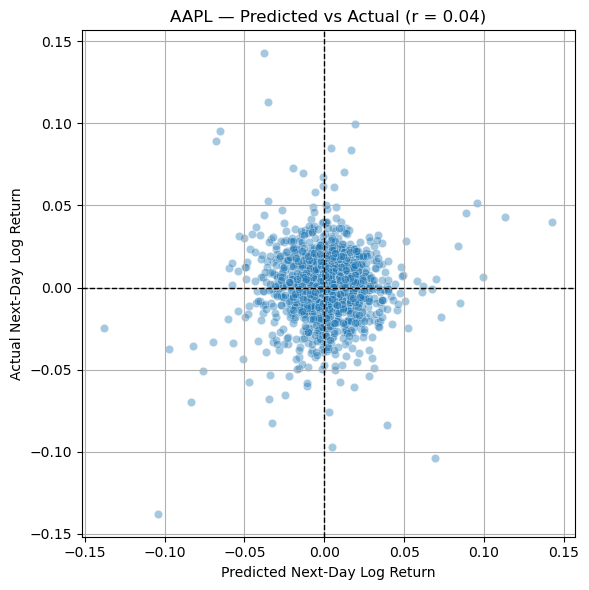

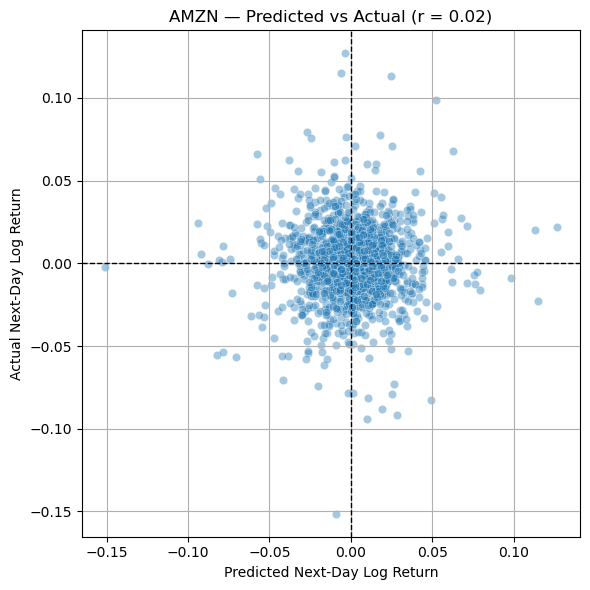

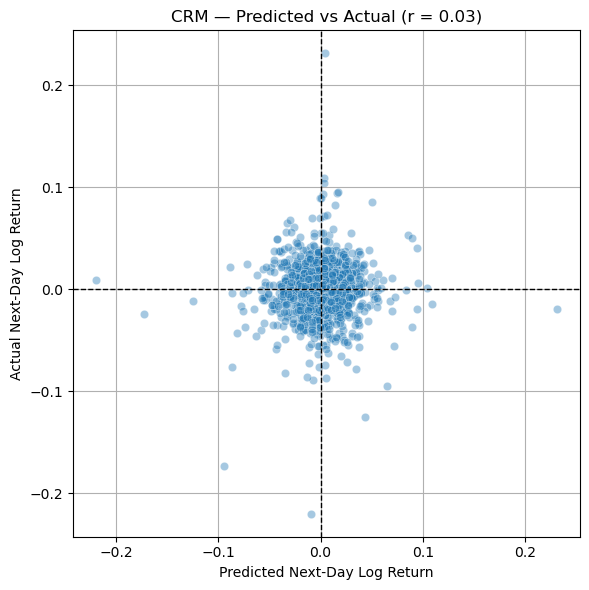

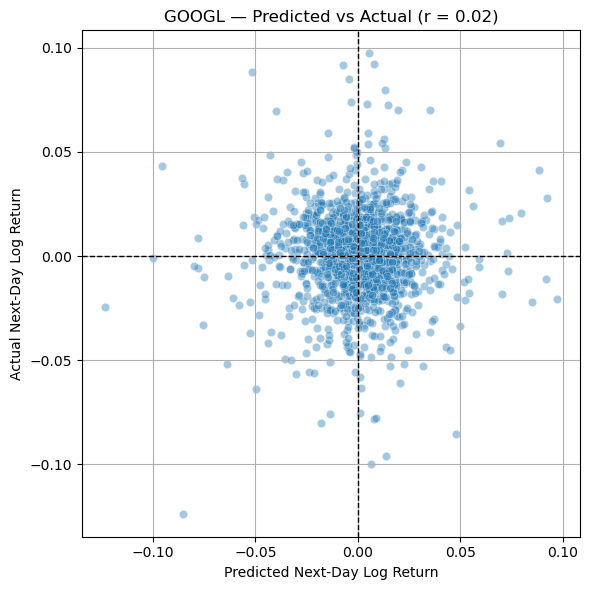

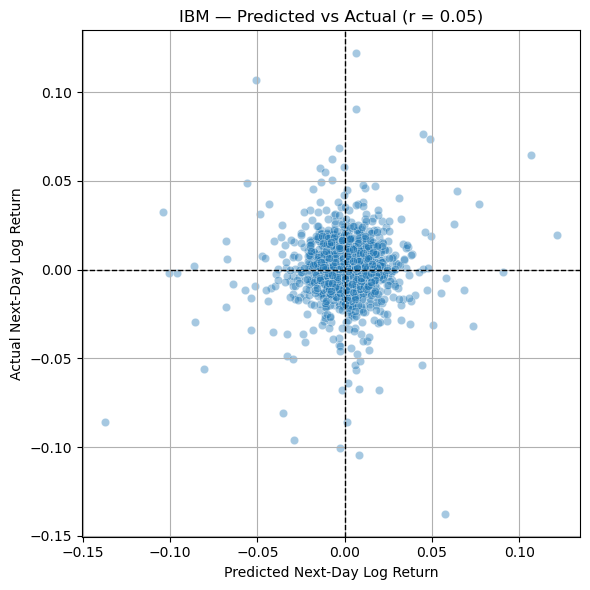

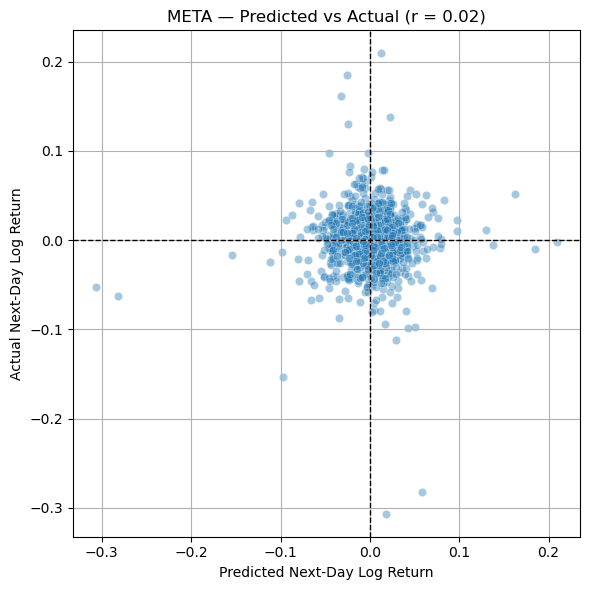

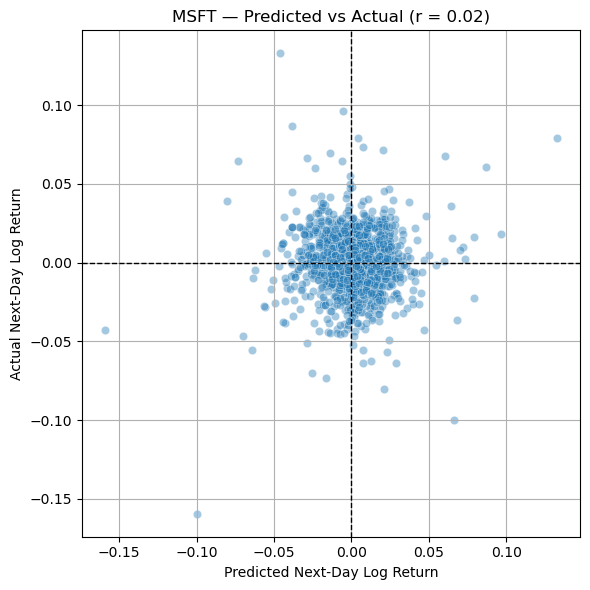

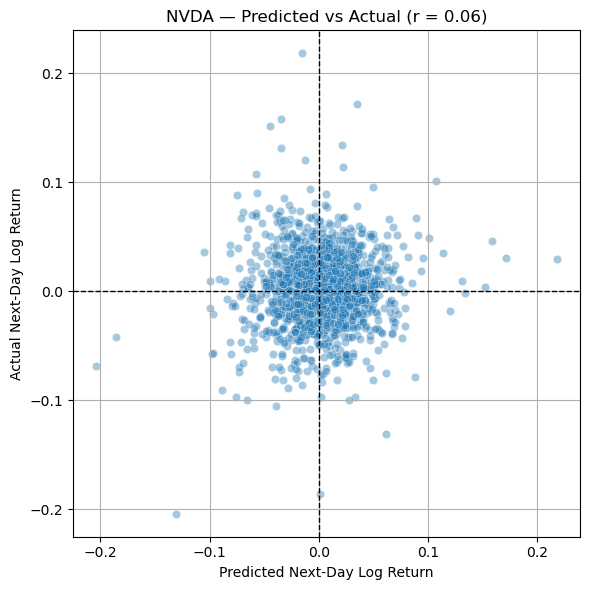

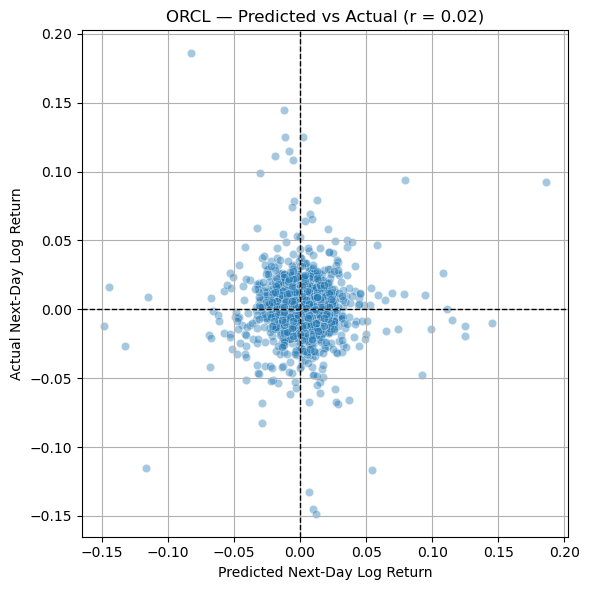

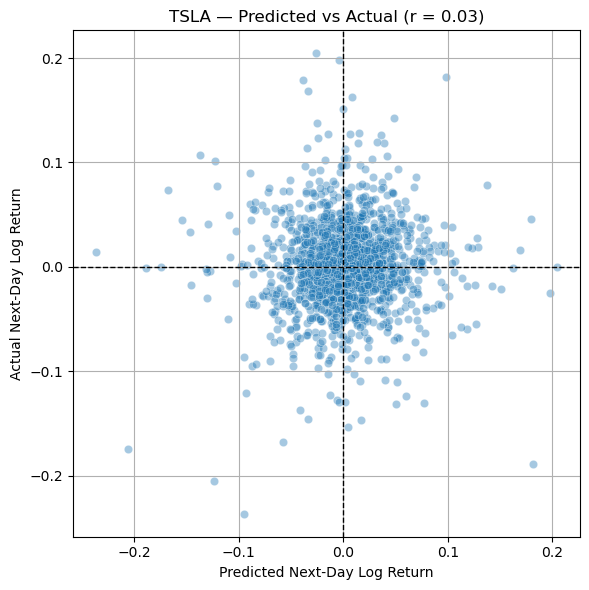

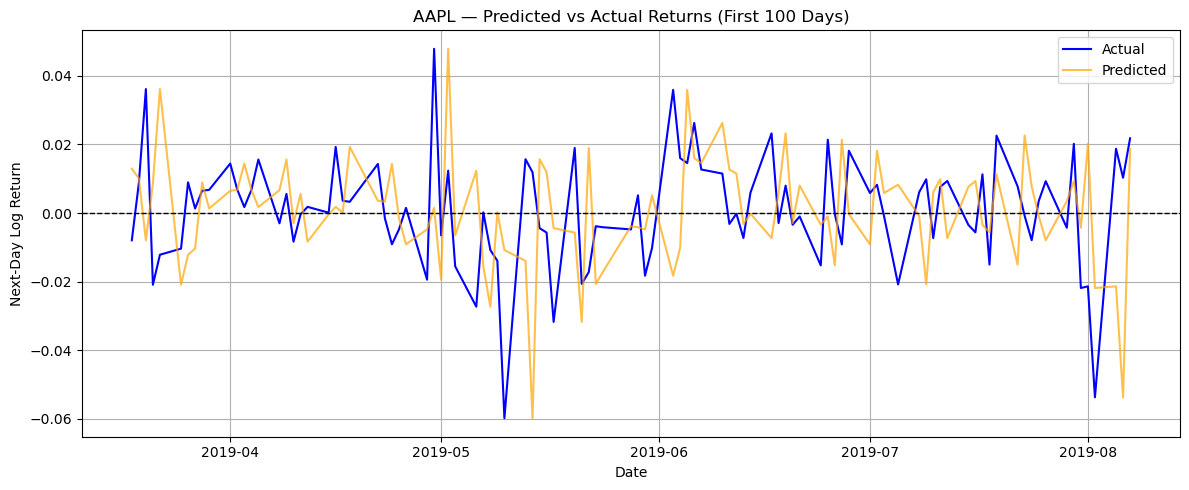

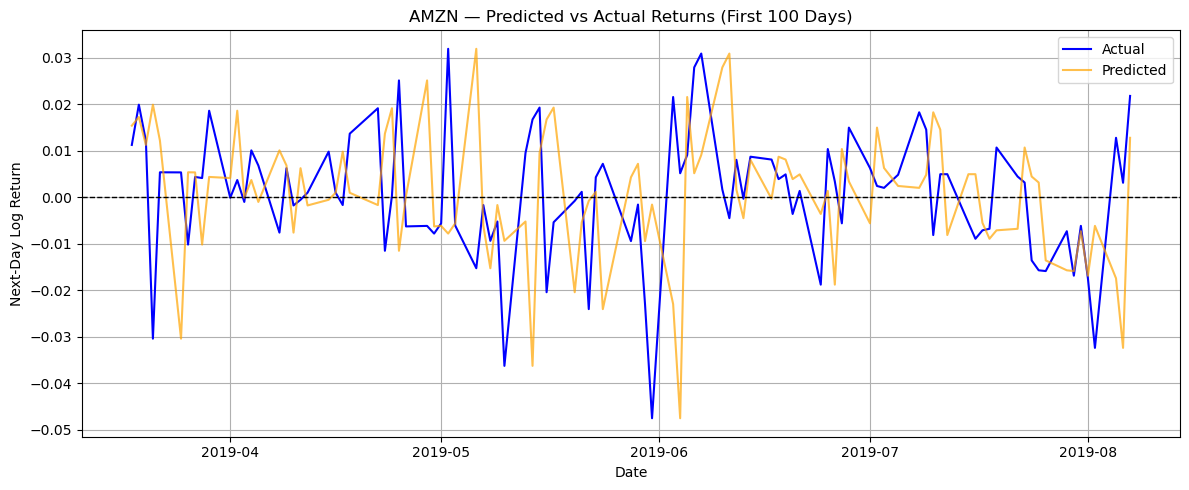

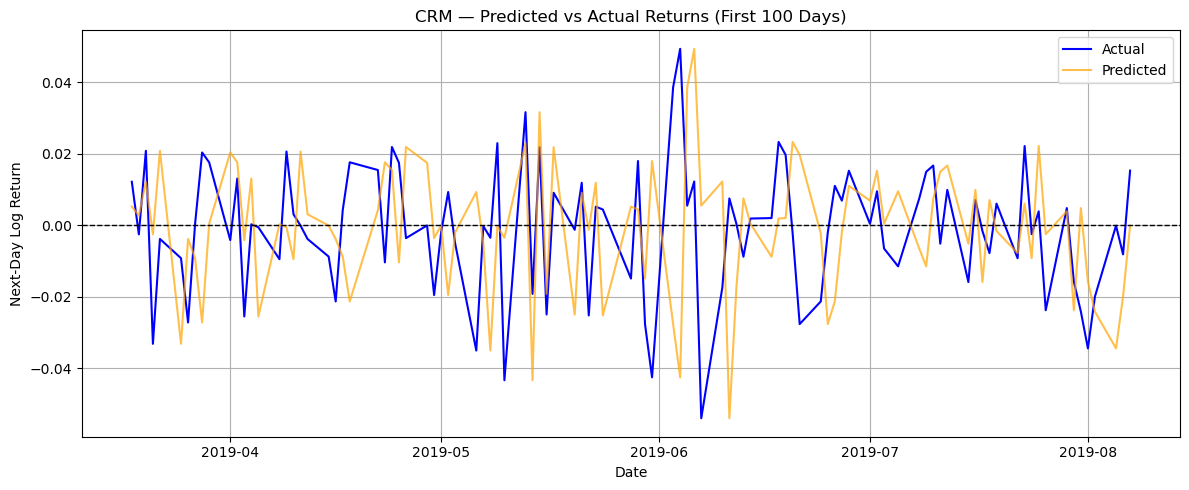

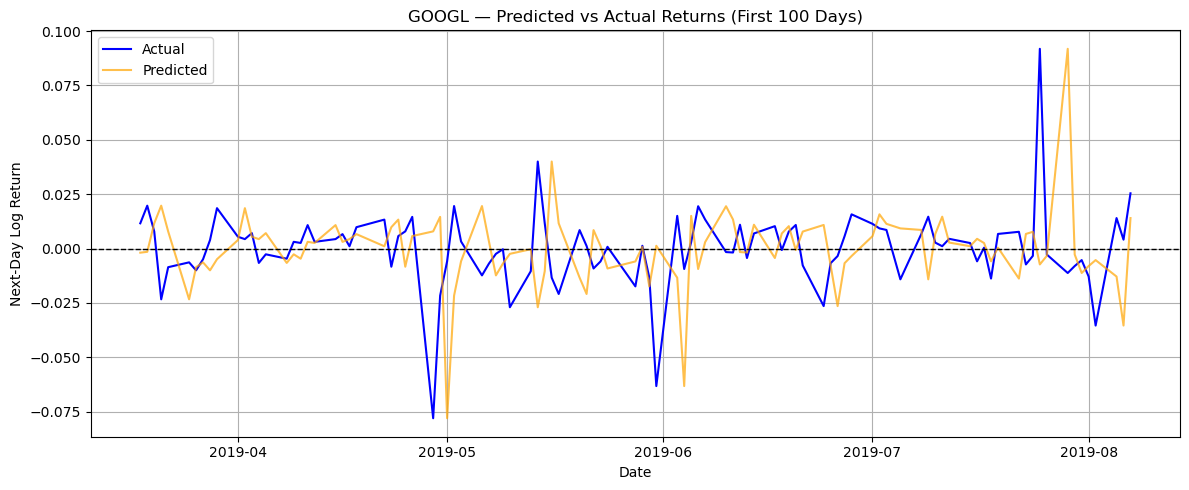

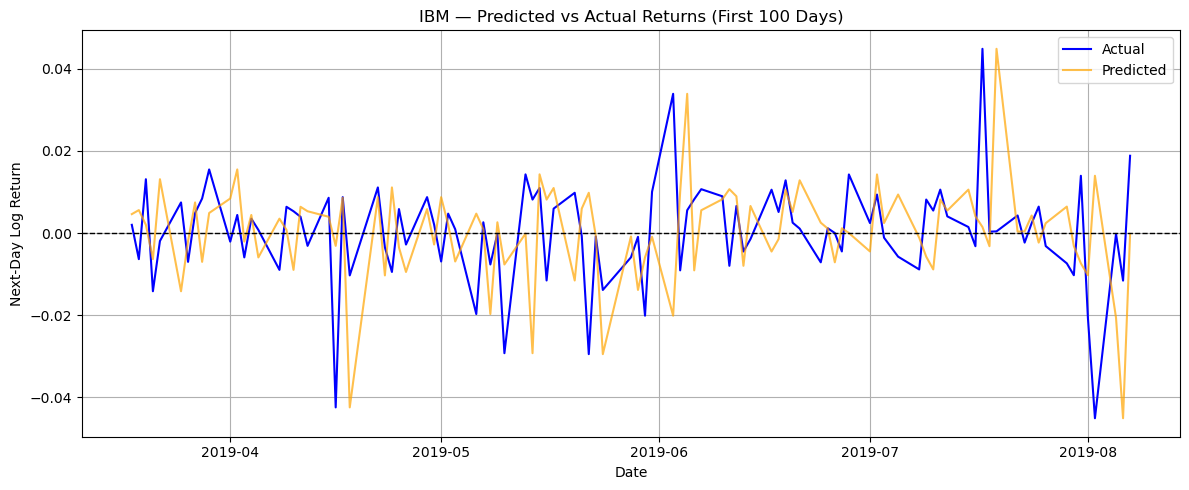

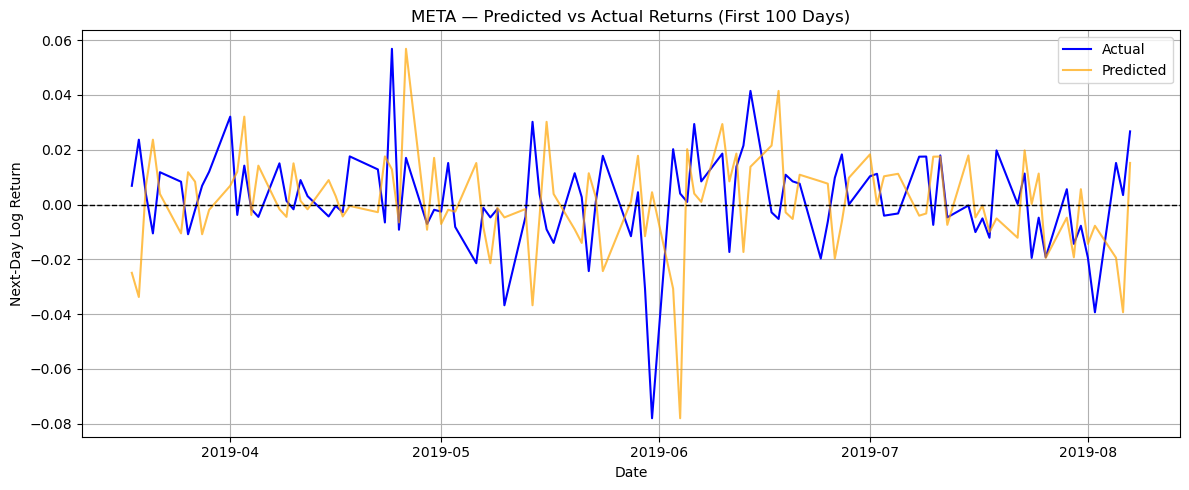

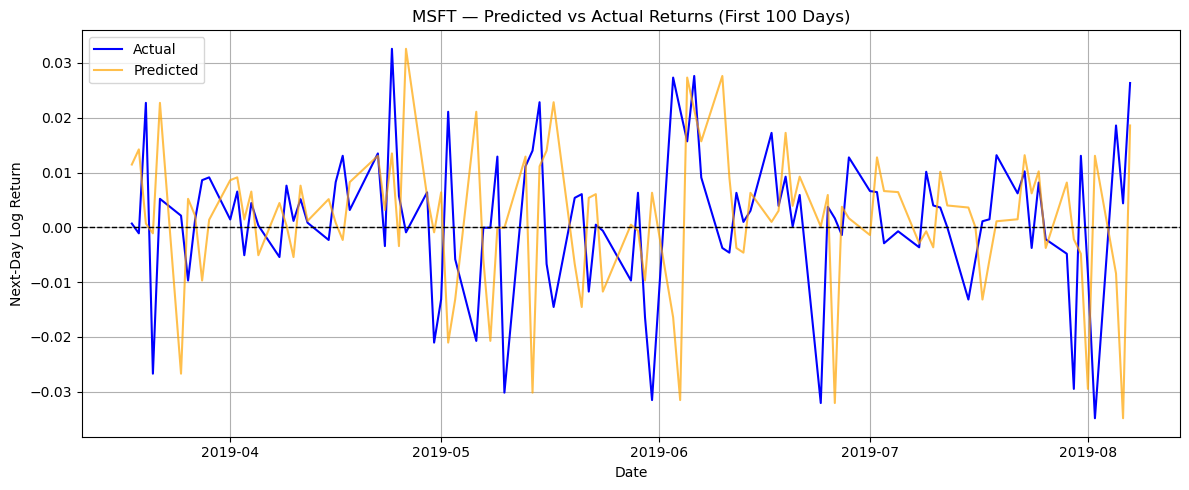

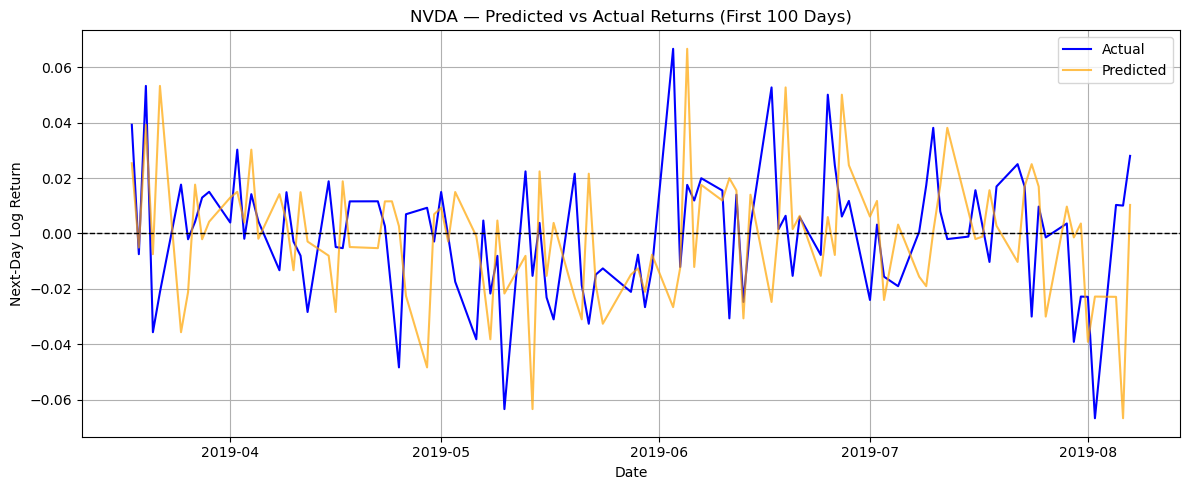

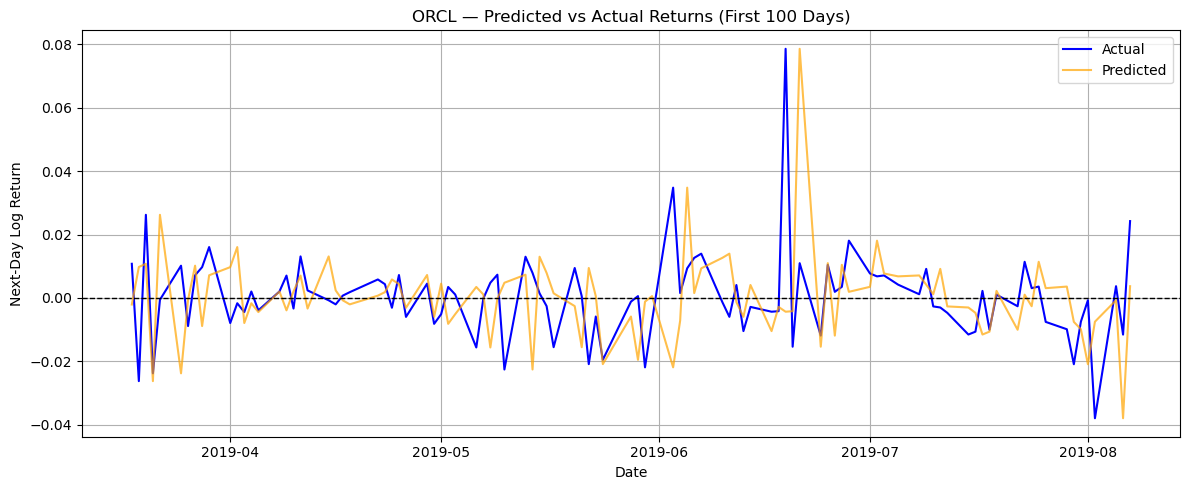

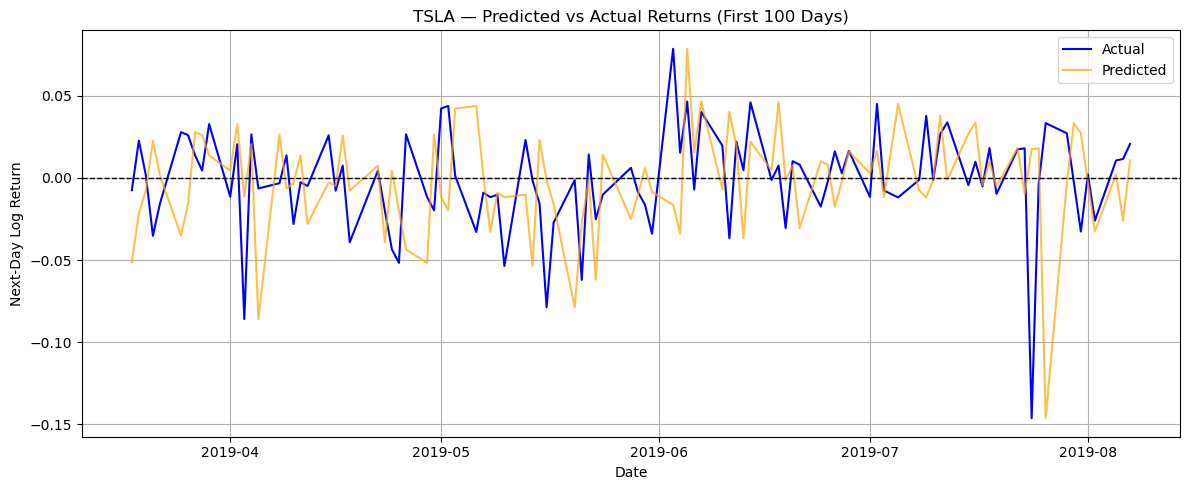

In [7]:
# Predicted vs. Actual plots
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

eval_df = pd.read_parquet(REPORT_DIR / "eval_table.parquet")

# scatter: Predicted vs Actual
def plot_scatter_all(df):
    for ticker in sorted(df['Ticker'].unique()):
        sub = df[df['Ticker'] == ticker]
        corr, _ = pearsonr(sub['y_pred'], sub['y_true'])

        plt.figure(figsize=(6,6))
        sns.scatterplot(x='y_pred', y='y_true', data=sub, alpha=0.4)
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.axvline(0, color='black', linestyle='--', linewidth=1)
        plt.xlabel("Predicted Next-Day Log Return")
        plt.ylabel("Actual Next-Day Log Return")
        plt.title(f"{ticker} — Predicted vs Actual (r = {corr:.2f})")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Time series overlay: First 100 days
def plot_time_overlay_all(df, n_days=100):
    for ticker in sorted(df['Ticker'].unique()):
        sub = df[df['Ticker'] == ticker].copy().reset_index(drop=True)
        sub = sub.iloc[:n_days]

        plt.figure(figsize=(12,5))
        plt.plot(sub['Date'], sub['y_true'], label="Actual", color='blue')
        plt.plot(sub['Date'], sub['y_pred'], label="Predicted", color='orange', alpha=0.7)
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.ylabel("Next-Day Log Return")
        plt.xlabel("Date")
        plt.title(f"{ticker} — Predicted vs Actual Returns (First {n_days} Days)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


plot_scatter_all(eval_df)
plot_time_overlay_all(eval_df, n_days=100)

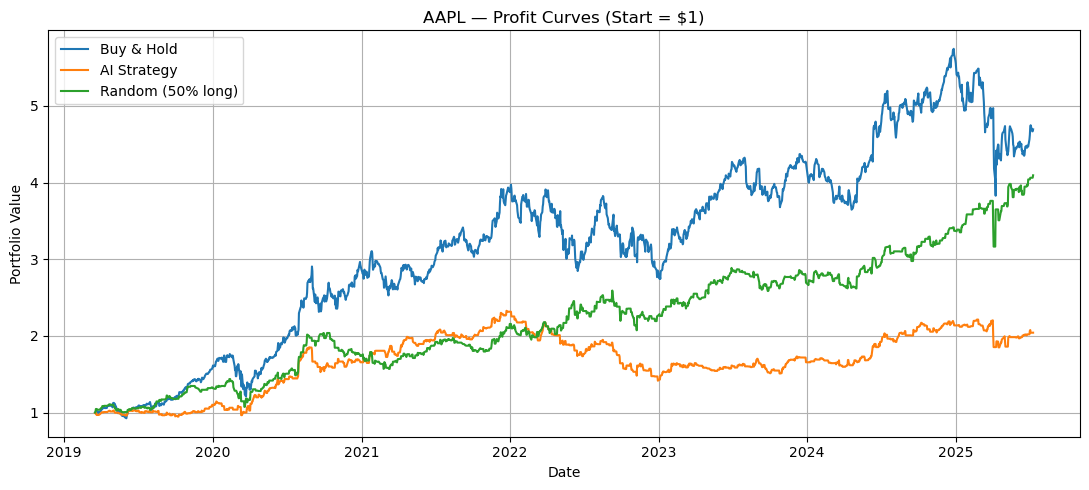

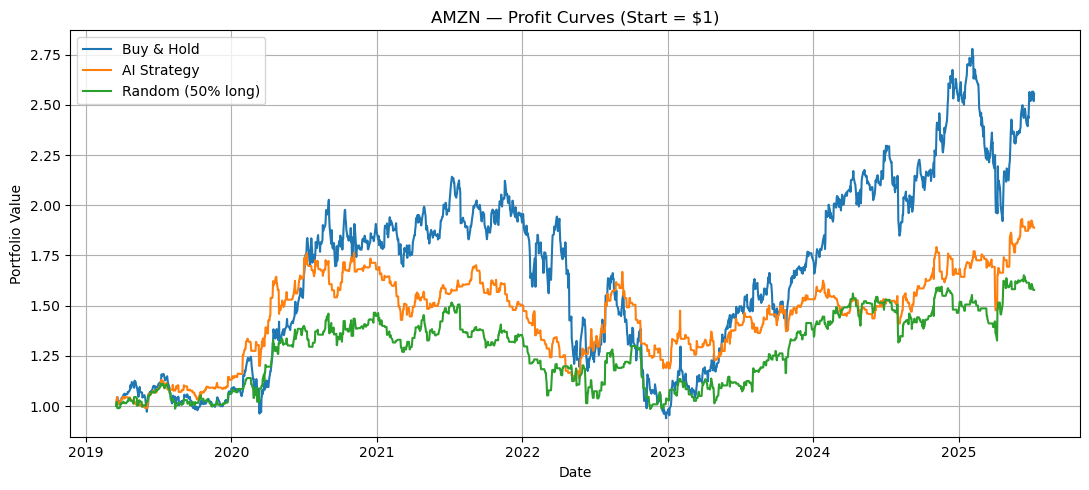

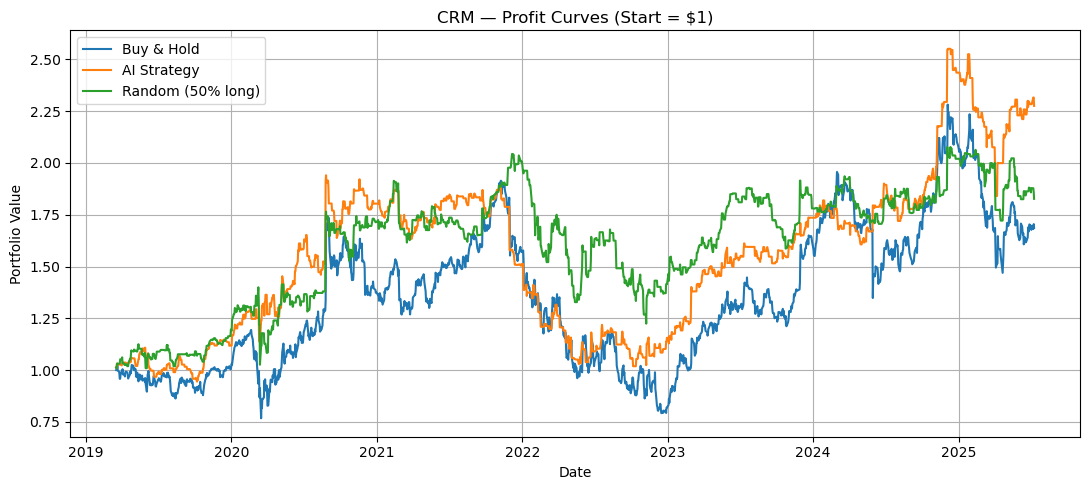

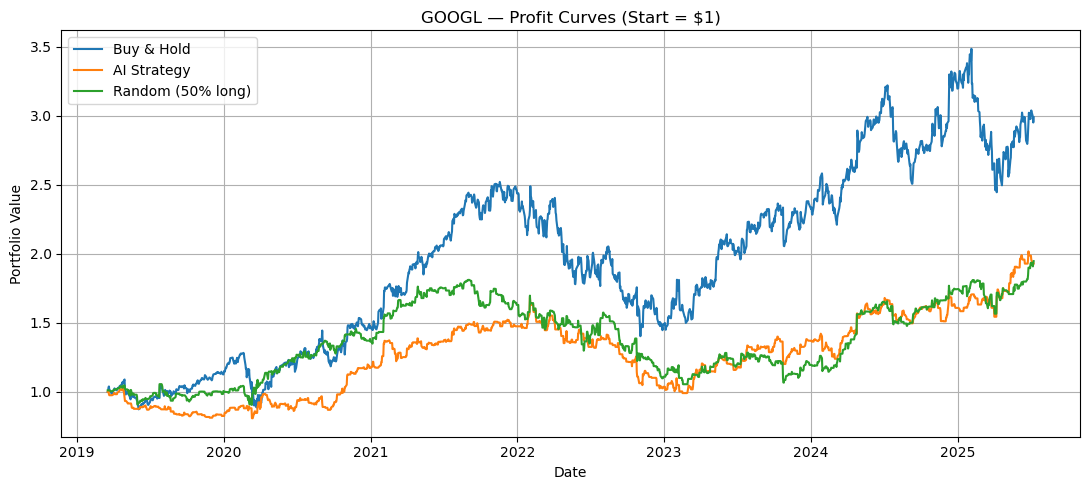

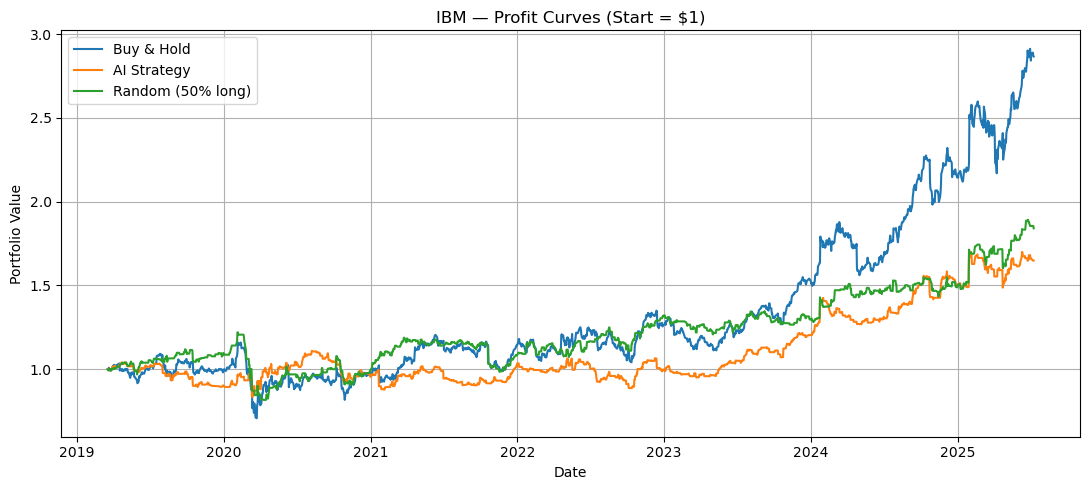

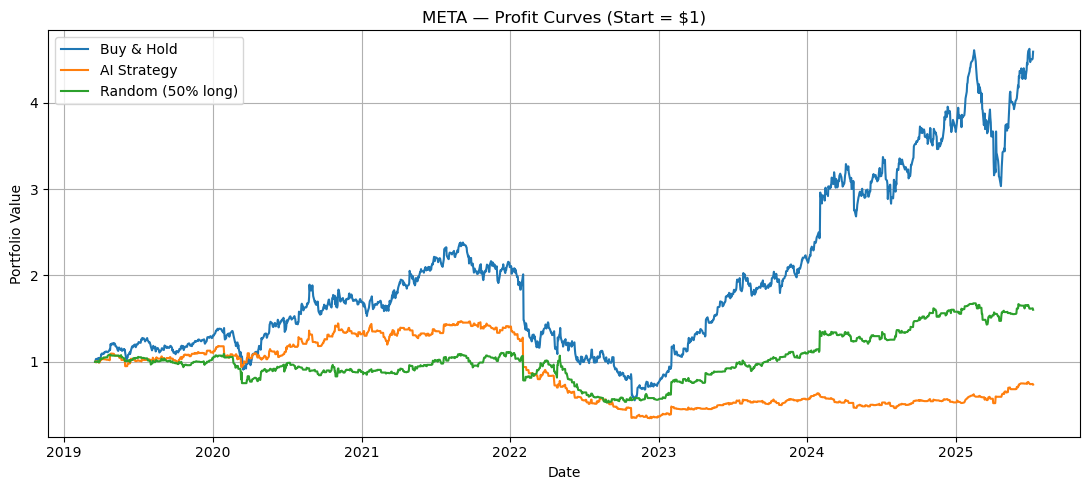

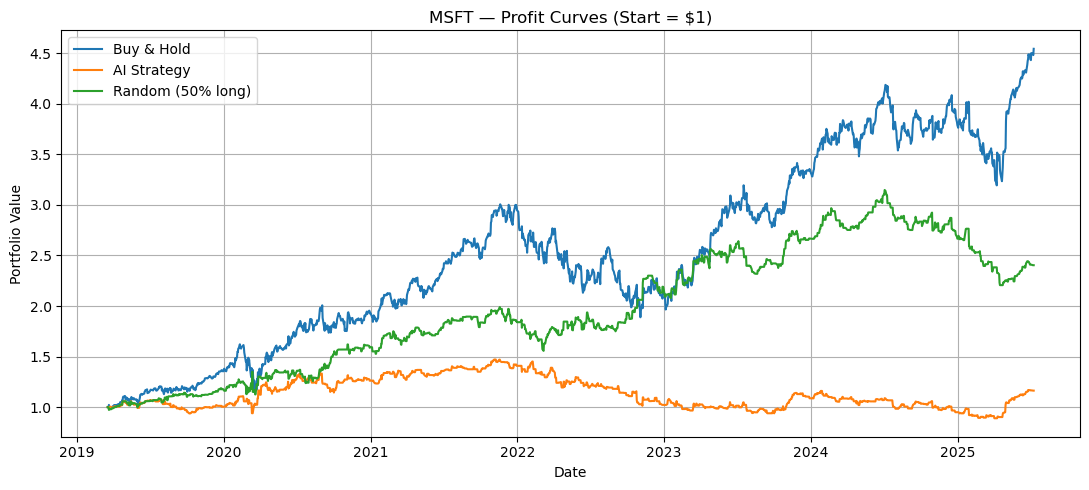

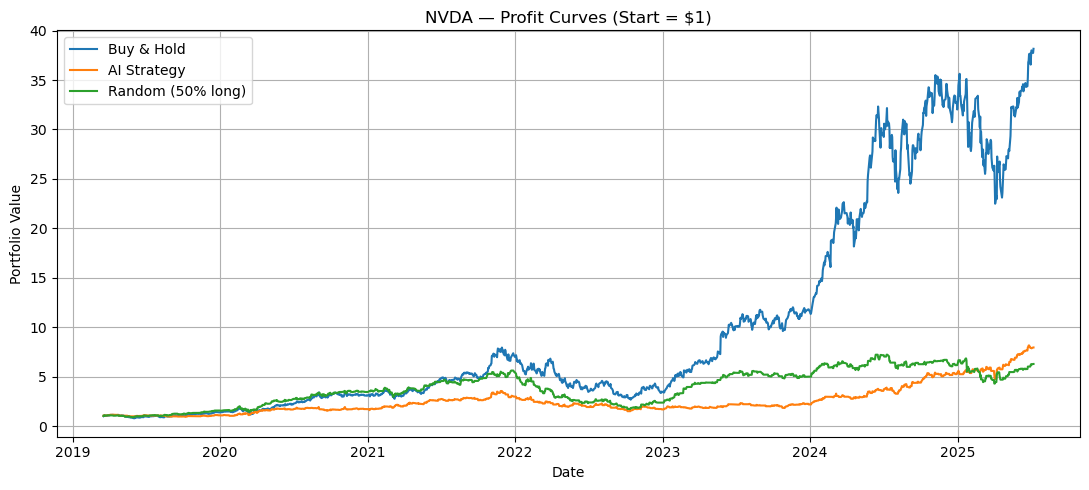

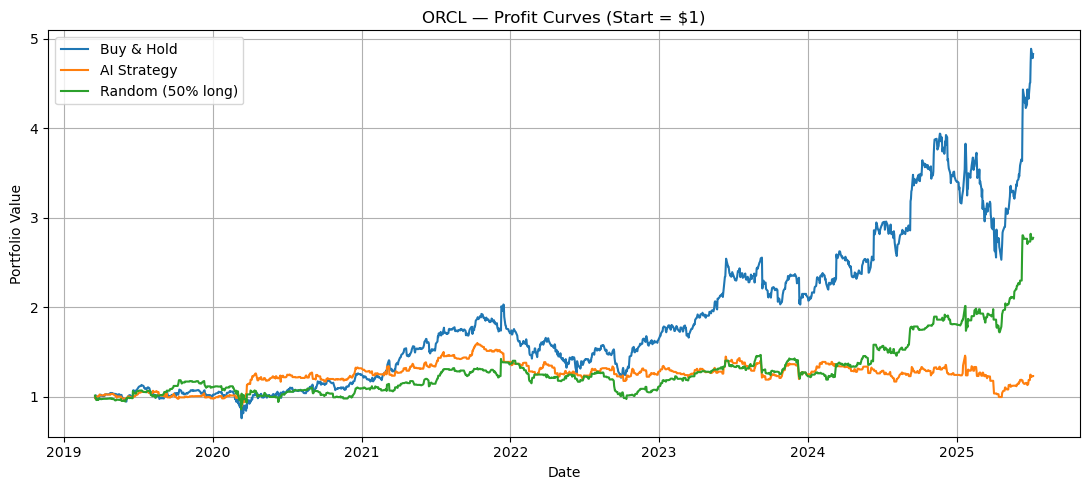

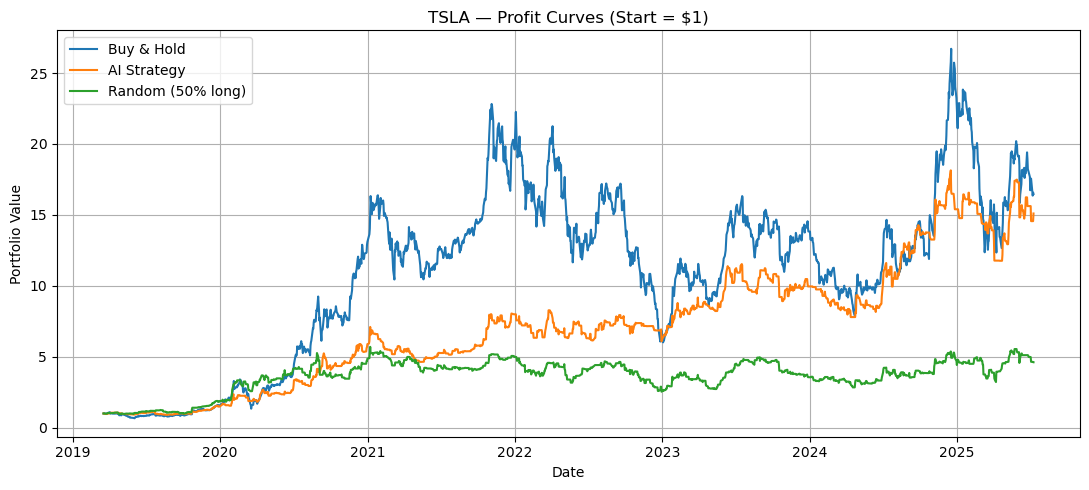

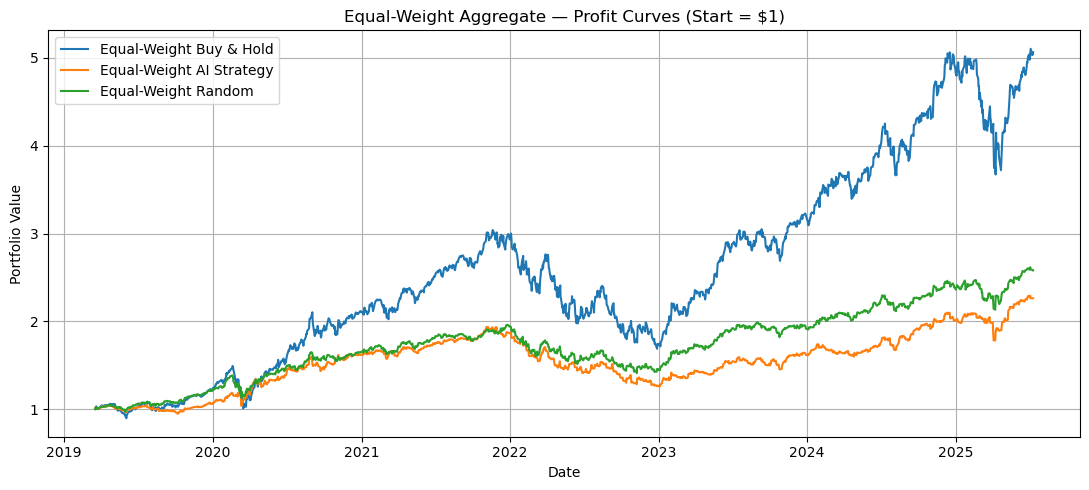

In [10]:
# Profit Curves (AI vs Buy-&-Hold vs Random).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

eval_df = pd.read_parquet(REPORT_DIR / "eval_table.parquet").copy()

# profit curves: AI vs Buy&Hold vs Random
def plot_profit_curves_all(df, seed=42):
    rng = np.random.default_rng(seed)
    all_for_agg = []

    for ticker in sorted(df['Ticker'].unique()):
        sub = df[df['Ticker'] == ticker].sort_values('Date').reset_index(drop=True).copy()
        sub['AI_Equity']  = np.exp(sub['StrategyReturn'].cumsum())
        sub['BH_Equity']  = np.exp(sub['Close'].pct_change().add(1).replace(0, np.nan).pipe(lambda s: np.log(s)).fillna(0).cumsum())
        # random baseline:: long (1) or flat (0) each day, 50/50, applied to y_true
        sub['Random_Signal'] = rng.integers(0, 2, size=len(sub))
        sub['Random_StrategyReturn'] = sub['Random_Signal'] * sub['y_true']
        sub['Random_Equity'] = np.exp(sub['Random_StrategyReturn'].cumsum())
        plt.figure(figsize=(11,5))
        plt.plot(sub['Date'], sub['BH_Equity'],      label='Buy & Hold')
        plt.plot(sub['Date'], sub['AI_Equity'],      label='AI Strategy')
        plt.plot(sub['Date'], sub['Random_Equity'],  label='Random (50% long)')
        plt.title(f"{ticker} — Profit Curves (Start = $1)")
        plt.xlabel("Date"); plt.ylabel("Portfolio Value")
        plt.grid(True); plt.legend(); plt.tight_layout()
        plt.show()

        all_for_agg.append(sub[['Date','Ticker','StrategyReturn','Random_StrategyReturn']].assign(
            BH_Return = np.log(sub['Close'] / sub['Close'].shift(1)).fillna(0)
        ))

    return pd.concat(all_for_agg, ignore_index=True)

per_ticker_returns = plot_profit_curves_all(eval_df)

# Equal weight
def plot_aggregate_curves(ret_df):
    daily_ai   = ret_df.pivot(index='Date', columns='Ticker', values='StrategyReturn').mean(axis=1, skipna=True)
    daily_bh   = ret_df.pivot(index='Date', columns='Ticker', values='BH_Return').mean(axis=1, skipna=True)
    daily_rand = ret_df.pivot(index='Date', columns='Ticker', values='Random_StrategyReturn').mean(axis=1, skipna=True)
    agg_ai_eq   = np.exp(daily_ai.cumsum())
    agg_bh_eq   = np.exp(daily_bh.cumsum())
    agg_rand_eq = np.exp(daily_rand.cumsum())

    plt.figure(figsize=(11,5))
    plt.plot(agg_bh_eq.index,   agg_bh_eq.values,   label='Equal-Weight Buy & Hold')
    plt.plot(agg_ai_eq.index,   agg_ai_eq.values,   label='Equal-Weight AI Strategy')
    plt.plot(agg_rand_eq.index, agg_rand_eq.values, label='Equal-Weight Random')
    plt.title("Equal-Weight Aggregate — Profit Curves (Start = $1)")
    plt.xlabel("Date"); plt.ylabel("Portfolio Value")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

plot_aggregate_curves(per_ticker_returns)


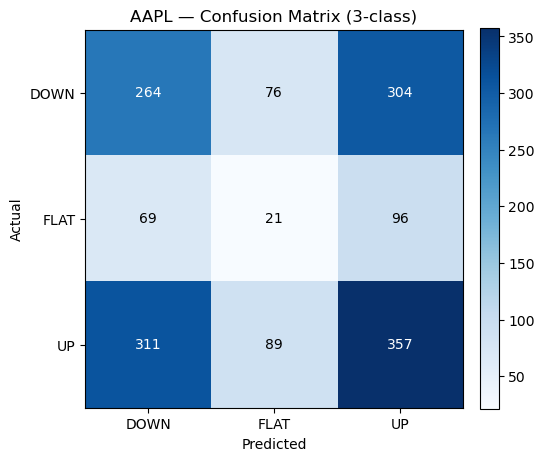

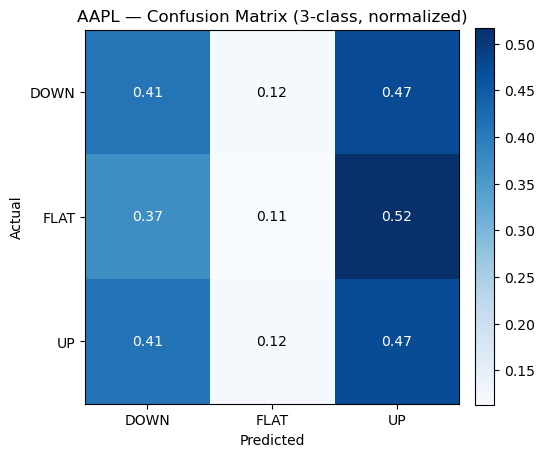

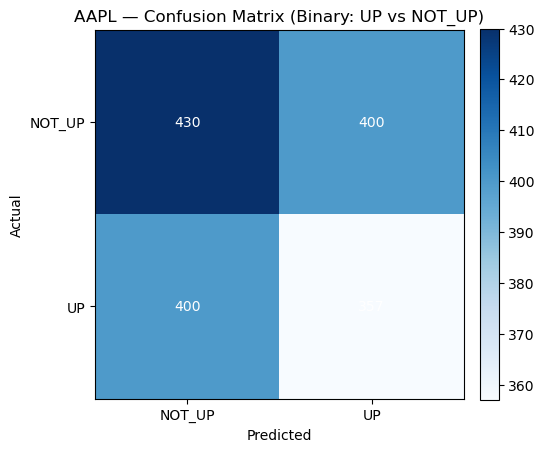

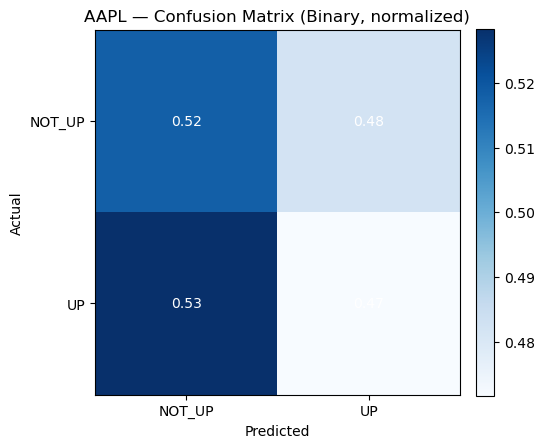

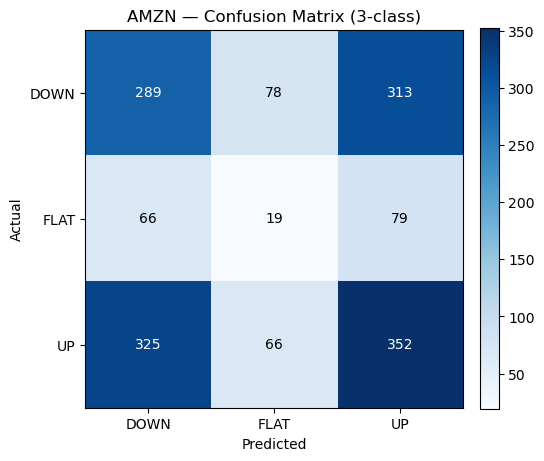

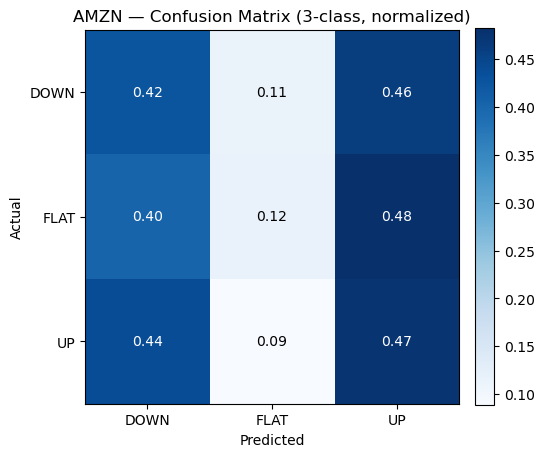

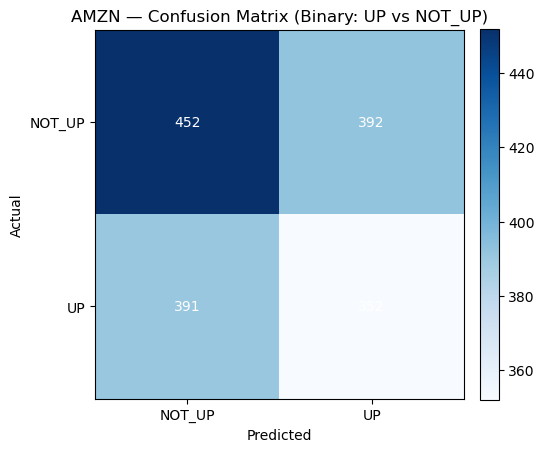

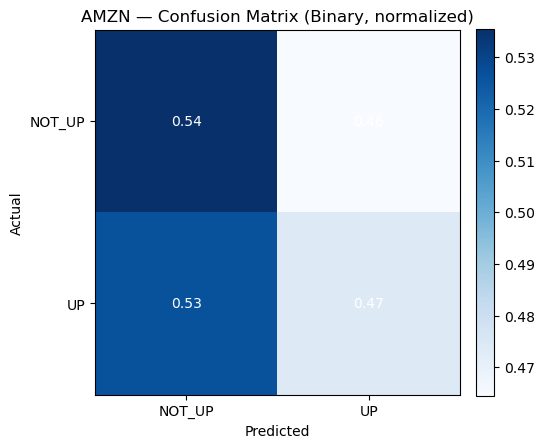

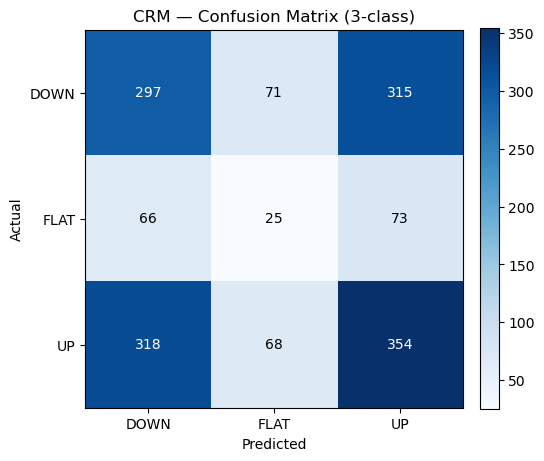

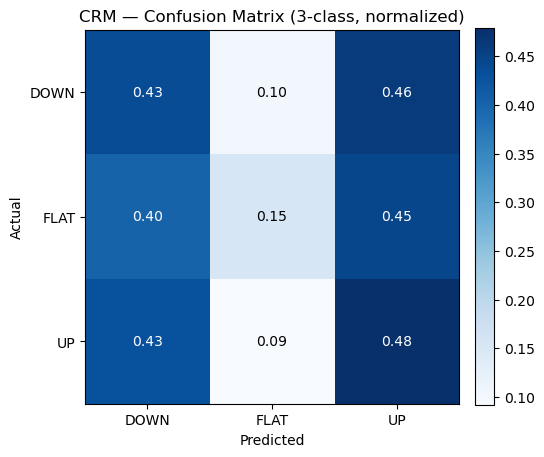

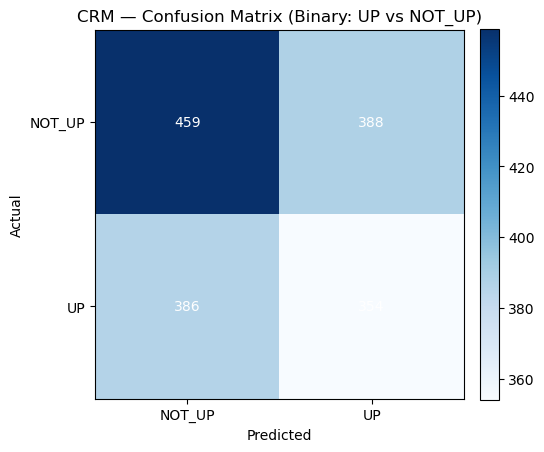

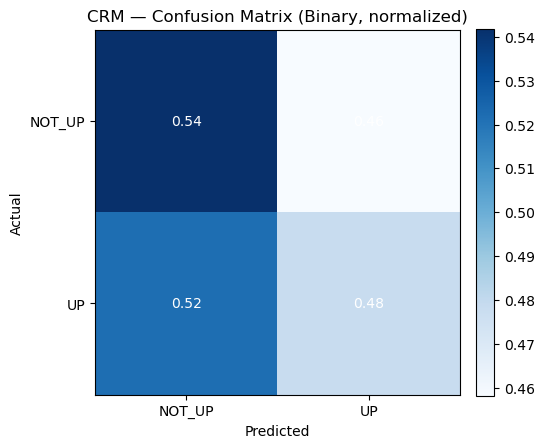

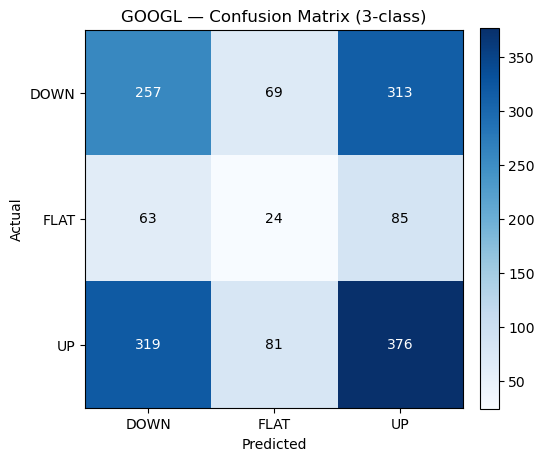

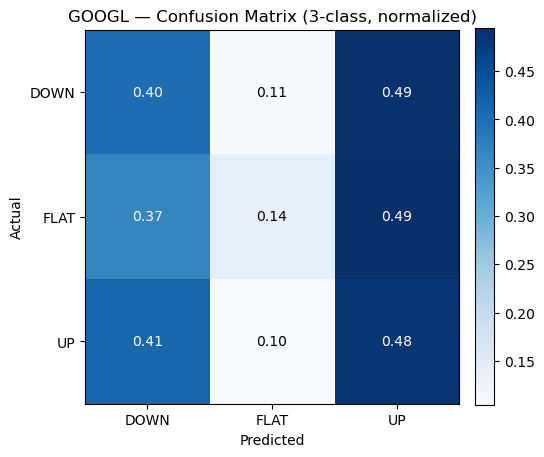

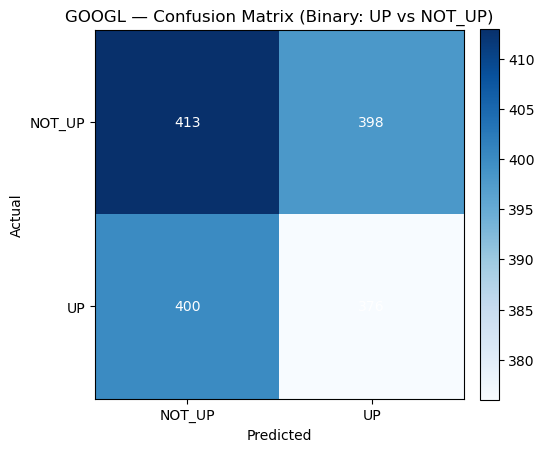

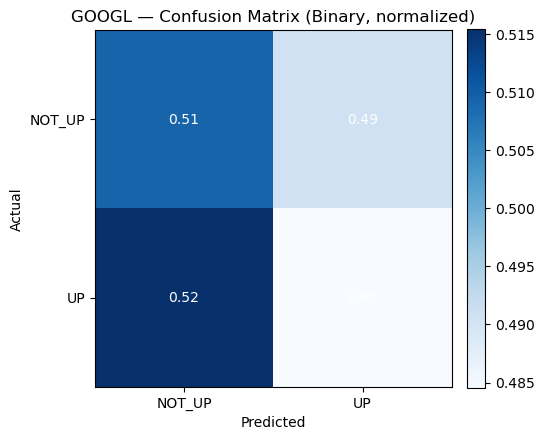

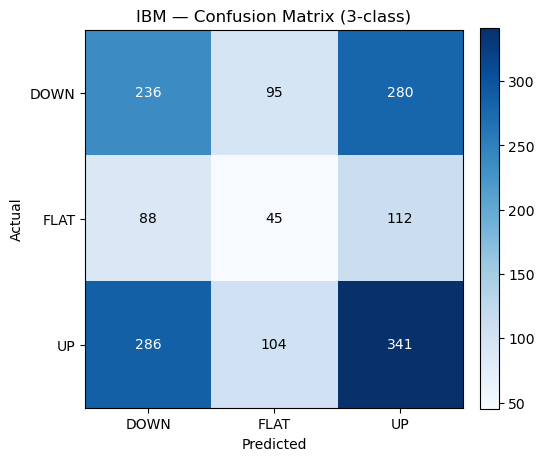

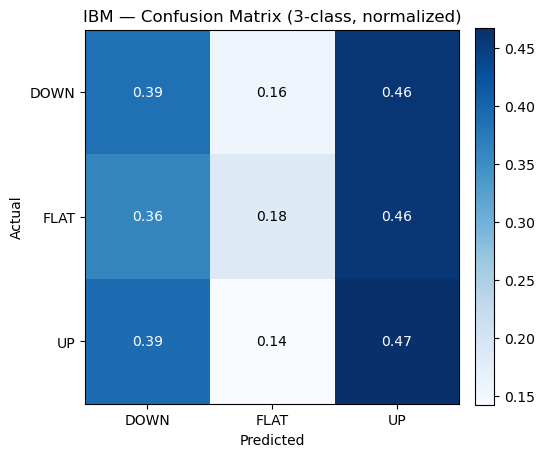

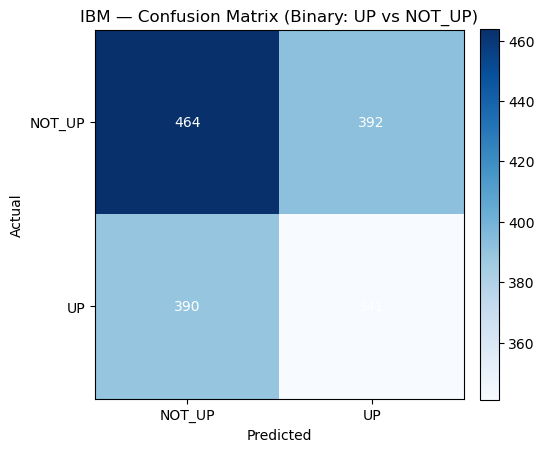

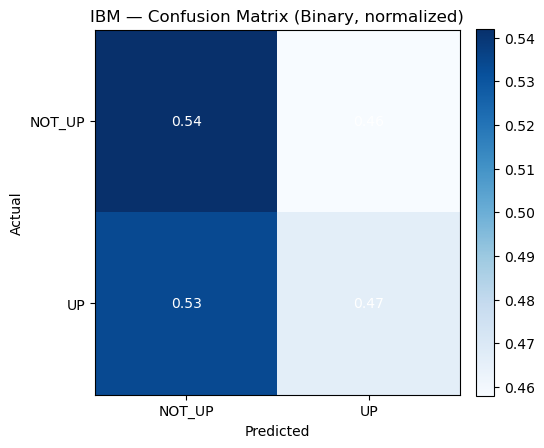

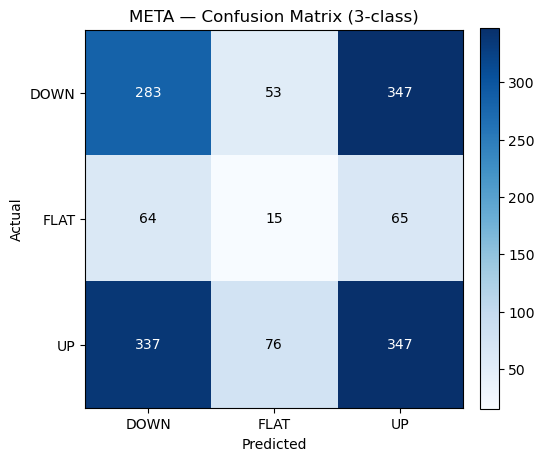

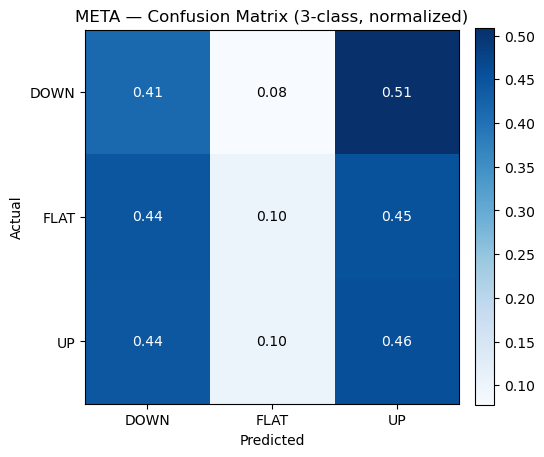

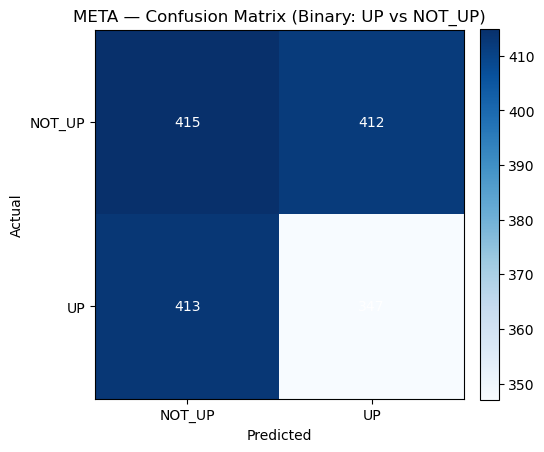

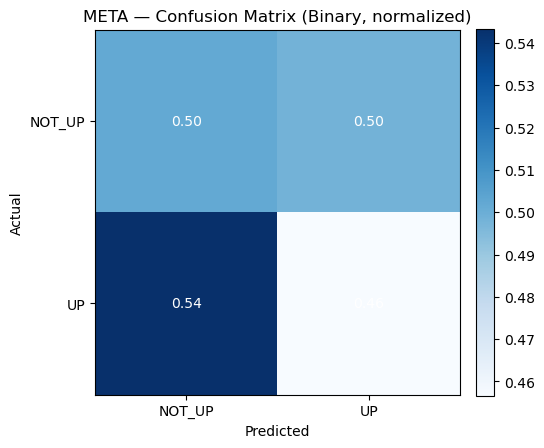

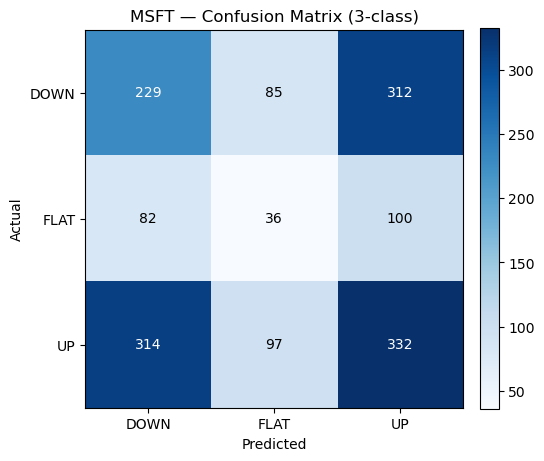

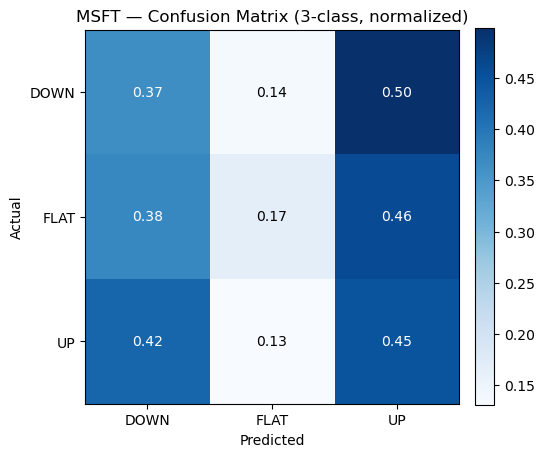

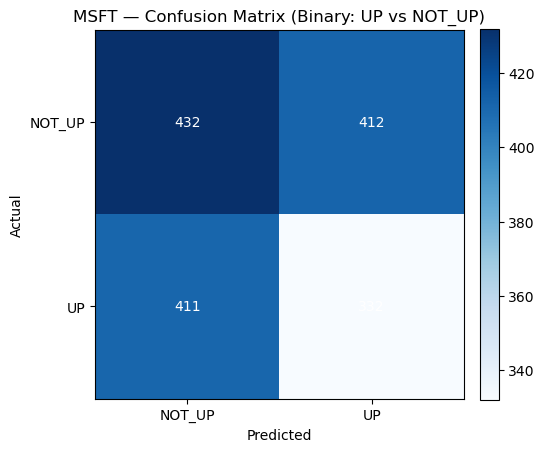

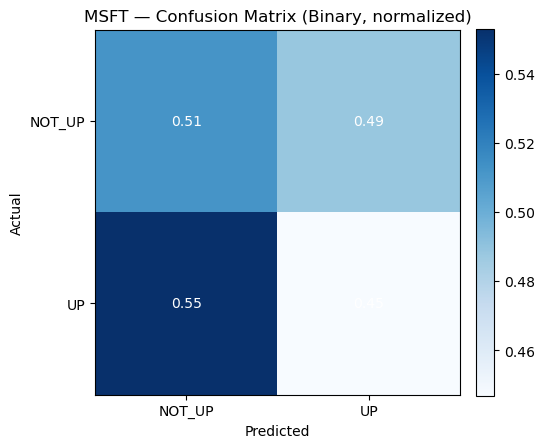

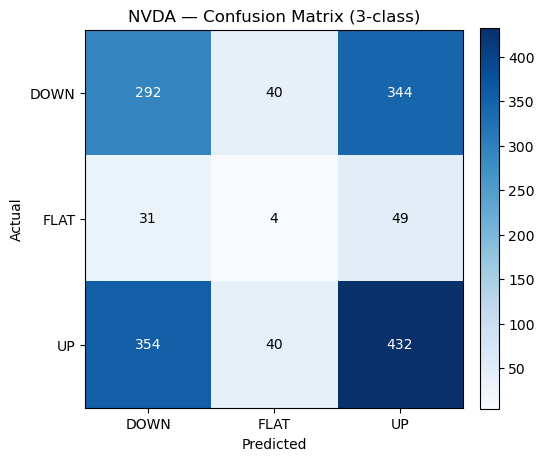

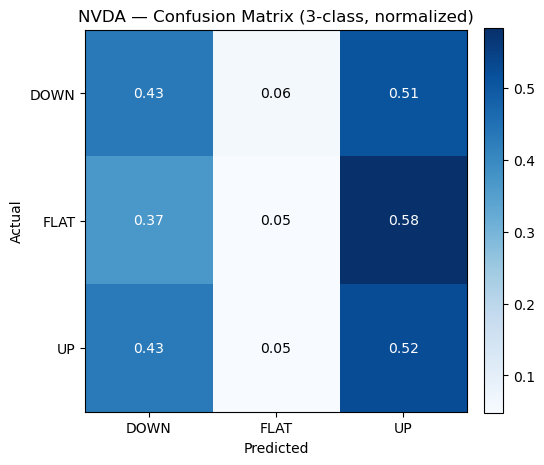

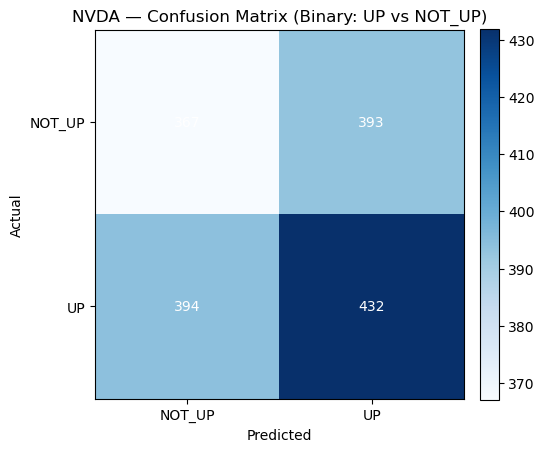

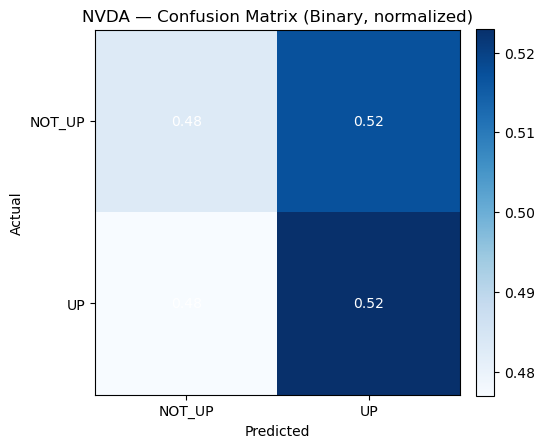

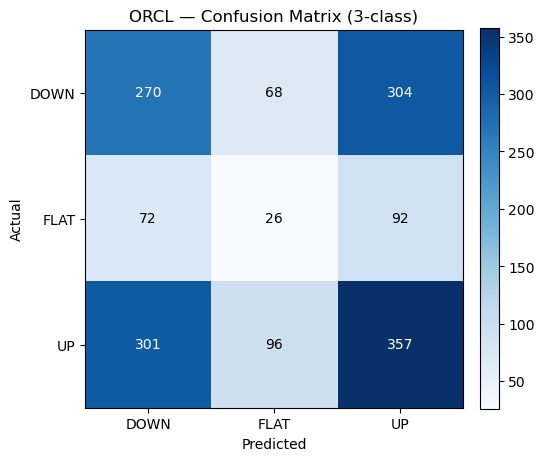

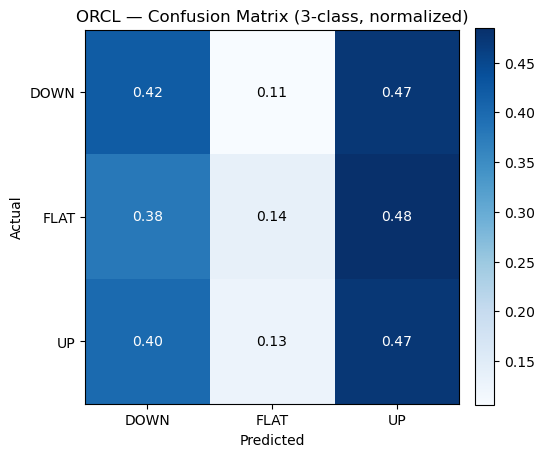

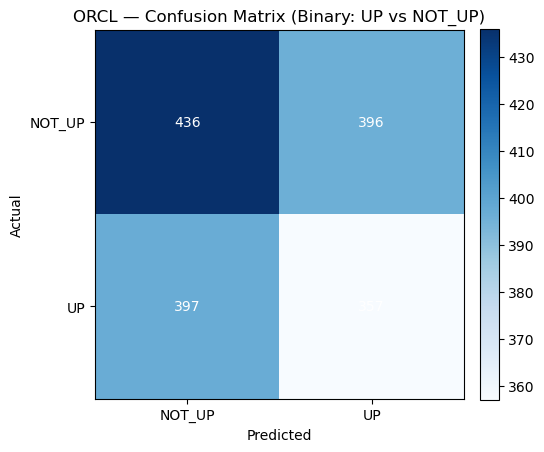

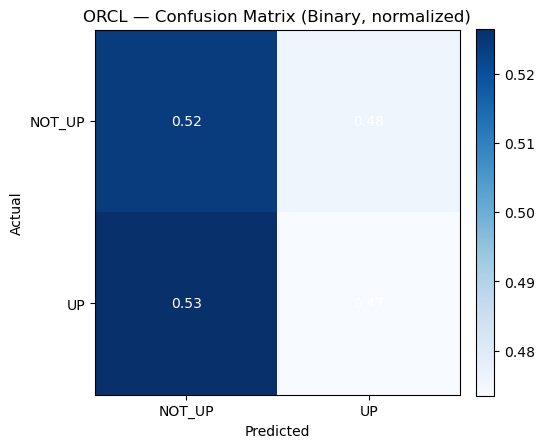

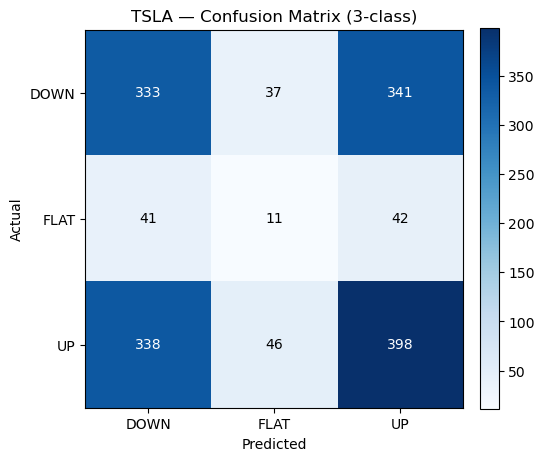

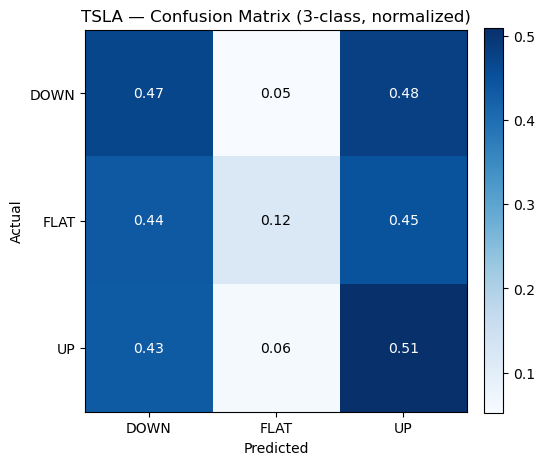

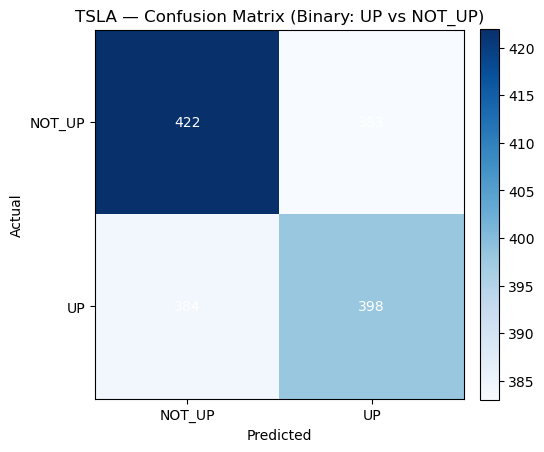

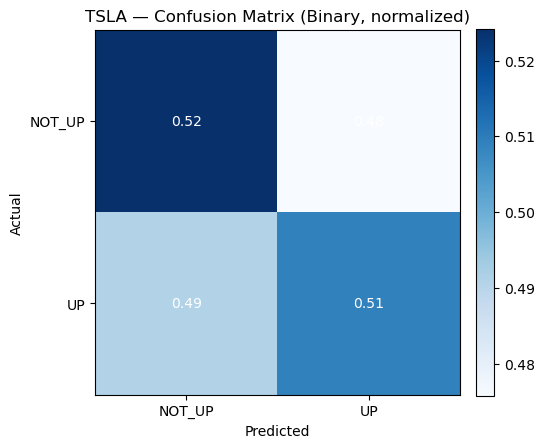

  Ticker  Acc_3c  Prec_3c  Rec_3c  F1_3c  Acc_bin  Prec_UP  Rec_UP  F1_UP
0   AAPL   0.405    0.331   0.331  0.331    0.496    0.472   0.472  0.472
1   AMZN   0.416    0.338   0.338  0.338    0.507    0.473   0.474  0.473
2    CRM   0.426    0.355   0.355  0.355    0.512    0.477   0.478  0.478
3  GOOGL   0.414    0.342   0.342  0.342    0.497    0.486   0.485  0.485
4    IBM   0.392    0.346   0.345  0.345    0.507    0.465   0.466  0.466
5   META   0.406    0.325   0.325  0.325    0.480    0.457   0.457  0.457
6   MSFT   0.376    0.326   0.326  0.326    0.481    0.446   0.447  0.447
7   NVDA   0.459    0.334   0.334  0.334    0.504    0.524   0.523  0.523
8   ORCL   0.412    0.344   0.344  0.344    0.500    0.474   0.473  0.474
9   TSLA   0.468    0.365   0.365  0.365    0.517    0.510   0.509  0.509


In [13]:
# Confusion Matrix (3-class and binary) + classification metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

eval_df = pd.read_parquet(REPORT_DIR / "eval_table.parquet").copy()
LABELS_3 = ["DOWN", "FLAT", "UP"]
BIN_MAP = {"DOWN":"NOT_UP", "FLAT":"NOT_UP", "UP":"UP"}
LABELS_BIN = ["NOT_UP", "UP"]

def plot_cm(cm, labels, title="Confusion Matrix", normalize=False):
    fig, ax = plt.subplots(figsize=(5.5, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    vmax = cm.max() if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            txt = f"{val:.2f}" if normalize else f"{int(val)}"
            ax.text(j, i, txt,
                    ha="center", va="center",
                    color=("black" if val < 0.6*vmax else "white"))
    plt.tight_layout()
    plt.show()

def per_ticker_metrics(df):
    rows = []
    for ticker in sorted(df["Ticker"].unique()):
        sub = df[df["Ticker"] == ticker]

        # 3-class
        y_true3 = pd.Categorical(sub["true_label"], categories=LABELS_3, ordered=True)
        y_pred3 = pd.Categorical(sub["pred_label"], categories=LABELS_3, ordered=True)

        acc3 = accuracy_score(y_true3, y_pred3)
        p3, r3, f3, _ = precision_recall_fscore_support(
            y_true3, y_pred3, labels=LABELS_3, zero_division=0, average="macro"
        )

        # Binary mapping via Series.map
        y_trueb = pd.Series(y_true3).map(BIN_MAP)
        y_predb = pd.Series(y_pred3).map(BIN_MAP)
        y_trueb = pd.Categorical(y_trueb, categories=LABELS_BIN, ordered=True)
        y_predb = pd.Categorical(y_predb, categories=LABELS_BIN, ordered=True)

        accb = accuracy_score(y_trueb, y_predb)
        pb, rb, fb, _ = precision_recall_fscore_support(
            y_trueb, y_predb, labels=LABELS_BIN, zero_division=0,
            average="binary", pos_label="UP"
        )

        rows.append({
            "Ticker": ticker,
            "Acc_3c": acc3, "Prec_3c": p3, "Rec_3c": r3, "F1_3c": f3,
            "Acc_bin": accb, "Prec_UP": pb, "Rec_UP": rb, "F1_UP": fb
        })
    return pd.DataFrame(rows)

for ticker in sorted(eval_df["Ticker"].unique()):
    sub = eval_df[eval_df["Ticker"] == ticker]
    y_true3 = pd.Categorical(sub["true_label"], categories=LABELS_3, ordered=True)
    y_pred3 = pd.Categorical(sub["pred_label"], categories=LABELS_3, ordered=True)
    cm3 = confusion_matrix(y_true3, y_pred3, labels=LABELS_3)
    cm3_norm = confusion_matrix(y_true3, y_pred3, labels=LABELS_3, normalize="true")
    plot_cm(cm3, LABELS_3, title=f"{ticker} — Confusion Matrix (3-class)")
    plot_cm(cm3_norm, LABELS_3, title=f"{ticker} — Confusion Matrix (3-class, normalized)", normalize=True)
    # Binary via Series.map
    y_trueb = pd.Series(y_true3).map(BIN_MAP)
    y_predb = pd.Series(y_pred3).map(BIN_MAP)
    y_trueb = pd.Categorical(y_trueb, categories=LABELS_BIN, ordered=True)
    y_predb = pd.Categorical(y_predb, categories=LABELS_BIN, ordered=True)
    cmb = confusion_matrix(y_trueb, y_predb, labels=LABELS_BIN)
    cmb_norm = confusion_matrix(y_trueb, y_predb, labels=LABELS_BIN, normalize="true")
    plot_cm(cmb, LABELS_BIN, title=f"{ticker} — Confusion Matrix (Binary: UP vs NOT_UP)")
    plot_cm(cmb_norm, LABELS_BIN, title=f"{ticker} — Confusion Matrix (Binary, normalized)", normalize=True)

metrics_df = per_ticker_metrics(eval_df)
with pd.option_context('display.float_format', '{:.3f}'.format):
    print(metrics_df.sort_values("Ticker"))

In [16]:
# Auto-summary report (markdown)
import pandas as pd
import numpy as np
from pathlib import Path

REPORT_DIR = Path("week10")
SAVE = True
eval_df = pd.read_parquet(REPORT_DIR / "eval_table.parquet").copy()

def sharpe_ratio(daily_returns, risk_free=0.0, periods=252):
    excess = daily_returns - risk_free/periods
    vol = excess.std()
    return (excess.mean() / vol) * np.sqrt(periods) if vol != 0 else np.nan

def max_drawdown(equity):
    roll_max = equity.cummax()
    dd = (equity - roll_max) / roll_max
    return dd.min()

LABELS_3 = ["DOWN","FLAT","UP"]
BIN_MAP = {"DOWN":"NOT_UP","FLAT":"NOT_UP","UP":"UP"}
LABELS_BIN = ["NOT_UP","UP"]

rows = []
for ticker in sorted(eval_df["Ticker"].unique()):
    sub = eval_df[eval_df["Ticker"] == ticker].sort_values("Date").copy()
    bh_ret = np.log(sub["Close"] / sub["Close"].shift(1)).fillna(0)
    ai_ret = sub["StrategyReturn"].fillna(0)
    bh_eq = np.exp(bh_ret.cumsum())
    ai_eq = np.exp(ai_ret.cumsum())

    # binary UP vs NOT_UP
    y_true3 = pd.Categorical(sub["true_label"], categories=LABELS_3, ordered=True)
    y_pred3 = pd.Categorical(sub["pred_label"], categories=LABELS_3, ordered=True)
    y_trueb = pd.Series(y_true3).map(BIN_MAP)
    y_predb = pd.Series(y_pred3).map(BIN_MAP)

    # binary precision/recall/F1 for UP class
    tp = ((y_trueb=="UP") & (y_predb=="UP")).sum()
    fp = ((y_trueb!="UP") & (y_predb=="UP")).sum()
    fn = ((y_trueb=="UP") & (y_predb!="UP")).sum()
    tn = ((y_trueb!="UP") & (y_predb!="UP")).sum()
    prec_up = tp / (tp+fp) if (tp+fp)>0 else np.nan
    rec_up  = tp / (tp+fn) if (tp+fn)>0 else np.nan
    f1_up   = 2*prec_up*rec_up/(prec_up+rec_up) if (prec_up+rec_up)>0 else np.nan
    acc_bin = (tp+tn) / (tp+tn+fp+fn) if (tp+tn+fp+fn)>0 else np.nan

    corr = np.corrcoef(sub["y_pred"], sub["y_true"])[0,1]
    rows.append({
        "Ticker": ticker,
        "AI_TotalReturn": ai_eq.iloc[-1] - 1.0,
        "BH_TotalReturn": bh_eq.iloc[-1] - 1.0,
        "AI_Sharpe": sharpe_ratio(ai_ret),
        "BH_Sharpe": sharpe_ratio(bh_ret),
        "AI_MaxDD": max_drawdown(ai_eq),
        "BH_MaxDD": max_drawdown(bh_eq),
        "Corr(y_pred,y_true)": corr,
        "Acc_bin": acc_bin,
        "F1_UP": f1_up,
        "Prec_UP": prec_up,
        "Rec_UP": rec_up,
    })

perf_df = pd.DataFrame(rows)

agg = {
    "AI_TotalReturn(mean)": perf_df["AI_TotalReturn"].mean(),
    "BH_TotalReturn(mean)": perf_df["BH_TotalReturn"].mean(),
    "AI_Sharpe(mean)": perf_df["AI_Sharpe"].mean(),
    "BH_Sharpe(mean)": perf_df["BH_Sharpe"].mean(),
    "AI_MaxDD(mean)": perf_df["AI_MaxDD"].mean(),
    "BH_MaxDD(mean)": perf_df["BH_MaxDD"].mean(),
    "Corr(mean)": perf_df["Corr(y_pred,y_true)"].mean(),
    "F1_UP(mean)": perf_df["F1_UP"].mean(),
    "Acc_bin(mean)": perf_df["Acc_bin"].mean(),
}

# top/bottom by AI_Sharpe
top_sharpe = perf_df.sort_values("AI_Sharpe", ascending=False).head(3)
bot_sharpe = perf_df.sort_values("AI_Sharpe", ascending=True).head(3)
risk_lines = []
if np.nanmean(perf_df["Corr(y_pred,y_true)"]) < 0.1:
    risk_lines.append("- Low correlation between predicted and actual next-day returns (< 0.10 on average) indicates weak pure forecasting signal.")
if np.nanmean(perf_df["F1_UP"]) < 0.55:
    risk_lines.append("- UP vs NOT_UP classification shows modest F1 (avg < 0.55); precision/recall tradeoff may not support aggressive long-only rules.")
if np.nanmean(perf_df["AI_Sharpe"]) < np.nanmean(perf_df["BH_Sharpe"]):
    risk_lines.append("- AI strategy Sharpe underperforms Buy-&-Hold on average; risk-adjusted performance not compelling.")
if np.nanmean(perf_df["AI_MaxDD"]) > np.nanmean(perf_df["BH_MaxDD"]):
    risk_lines.append("- Strategy drawdowns are not consistently lower than Buy-&-Hold; limited downside protection.")
risk_lines += [
    "- Possible regime sensitivity: performance varies widely by ticker; model may overfit stock-specific patterns.",
    "- Transaction costs, slippage, borrow constraints, and taxes are **not** included; live performance will be lower.",
    "- Signal uses daily close-to-close; intraday execution and delays could materially change P&L.",
]

def fmt_pct(x): 
    return "NA" if pd.isna(x) else f"{x:.2%}"
def fmt2(x):
    return "NA" if pd.isna(x) else f"{x:.2f}"

md = []
md.append("# Week 10 — Model Evaluation Summary\n")
md.append("## Overview\n")
md.append("- Universe: {} tickers\n".format(perf_df.shape[0]))
md.append("- Horizon: Next-day log-return prediction; trading rule = long when predicted > +0.2%, else flat.\n")

md.append("## Aggregate Snapshot (means across tickers)\n")
md.append("| Metric | Value |\n|---|---|\n")
md.append(f"| AI Total Return (mean) | {fmt_pct(agg['AI_TotalReturn(mean)'])} |\n")
md.append(f"| Buy-&-Hold Total Return (mean) | {fmt_pct(agg['BH_TotalReturn(mean)'])} |\n")
md.append(f"| AI Sharpe (mean) | {fmt2(agg['AI_Sharpe(mean)'])} |\n")
md.append(f"| BH Sharpe (mean) | {fmt2(agg['BH_Sharpe(mean)'])} |\n")
md.append(f"| AI Max Drawdown (mean) | {fmt_pct(agg['AI_MaxDD(mean)'])} |\n")
md.append(f"| BH Max Drawdown (mean) | {fmt_pct(agg['BH_MaxDD(mean)'])} |\n")
md.append(f"| Corr(y_pred, y_true) (mean) | {fmt2(agg['Corr(mean)'])} |\n")
md.append(f"| F1 (UP vs NOT_UP) (mean) | {fmt2(agg['F1_UP(mean)'])} |\n")
md.append(f"| Accuracy (binary) (mean) | {fmt2(agg['Acc_bin(mean)'])} |\n")

md.append("\n## Top 3 Tickers by AI Sharpe\n")
md.append("| Ticker | AI Sharpe | AI TotalRet | AI MaxDD | Corr | F1_UP |\n|---|---:|---:|---:|---:|---:|\n")
for _, r in top_sharpe.iterrows():
    md.append(f"| {r.Ticker} | {fmt2(r.AI_Sharpe)} | {fmt_pct(r.AI_TotalReturn)} | {fmt_pct(r.AI_MaxDD)} | {fmt2(r['Corr(y_pred,y_true)'])} | {fmt2(r.F1_UP)} |\n")

md.append("\n## Bottom 3 Tickers by AI Sharpe\n")
md.append("| Ticker | AI Sharpe | AI TotalRet | AI MaxDD | Corr | F1_UP |\n|---|---:|---:|---:|---:|---:|\n")
for _, r in bot_sharpe.iterrows():
    md.append(f"| {r.Ticker} | {fmt2(r.AI_Sharpe)} | {fmt_pct(r.AI_TotalReturn)} | {fmt_pct(r.AI_MaxDD)} | {fmt2(r['Corr(y_pred,y_true)'])} | {fmt2(r.F1_UP)} |\n")

md.append("\n## Errors, Risks, and Model Limitations\n")
for line in risk_lines:
    md.append(f"{line}\n")

md.append("\n## Best Model & Result\n")
model_names = eval_df["model_name"].dropna().unique().tolist()
model_str = ", ".join(model_names) if model_names else "N/A"
best_row = top_sharpe.iloc[0]
md.append(f"- Current model(s): **{model_str}**.\n")
md.append(f"- Best ticker by Sharpe: **{best_row.Ticker}** (Sharpe {fmt2(best_row.AI_Sharpe)}, "
          f"Total return {fmt_pct(best_row.AI_TotalReturn)}, MaxDD {fmt_pct(best_row.AI_MaxDD)}).\n")
md.append("- Recommendation: prioritize feature/pipeline upgrades and calibrate thresholding; see Step 6 (reliability) before deployment.\n")
report_md = "".join(md)
print(report_md)

if SAVE:
    (REPORT_DIR / "model_evaluation_report.md").write_text(report_md)
    perf_df.sort_values("Ticker").to_csv(REPORT_DIR / "per_ticker_performance.csv", index=False)
    print("\nSaved:")
    print(REPORT_DIR / "model_evaluation_report.md")
    print(REPORT_DIR / "per_ticker_performance.csv")


# Week 10 — Model Evaluation Summary
## Overview
- Universe: 10 tickers
- Horizon: Next-day log-return prediction; trading rule = long when predicted > +0.2%, else flat.
## Aggregate Snapshot (means across tickers)
| Metric | Value |
|---|---|
| AI Total Return (mean) | 259.64% |
| Buy-&-Hold Total Return (mean) | 733.80% |
| AI Sharpe (mean) | 0.45 |
| BH Sharpe (mean) | 0.65 |
| AI Max Drawdown (mean) | -43.11% |
| BH Max Drawdown (mean) | -52.56% |
| Corr(y_pred, y_true) (mean) | 0.03 |
| F1 (UP vs NOT_UP) (mean) | 0.48 |
| Accuracy (binary) (mean) | 0.50 |

## Top 3 Tickers by AI Sharpe
| Ticker | AI Sharpe | AI TotalRet | AI MaxDD | Corr | F1_UP |
|---|---:|---:|---:|---:|---:|
| TSLA | 0.99 | 1409.93% | -35.14% | 0.03 | 0.51 |
| NVDA | 0.96 | 695.13% | -57.50% | 0.06 | 0.52 |
| AAPL | 0.56 | 104.14% | -39.18% | 0.04 | 0.47 |

## Bottom 3 Tickers by AI Sharpe
| Ticker | AI Sharpe | AI TotalRet | AI MaxDD | Corr | F1_UP |
|---|---:|---:|---:|---:|---:|
| META | -0.15 | -26.41% | -7

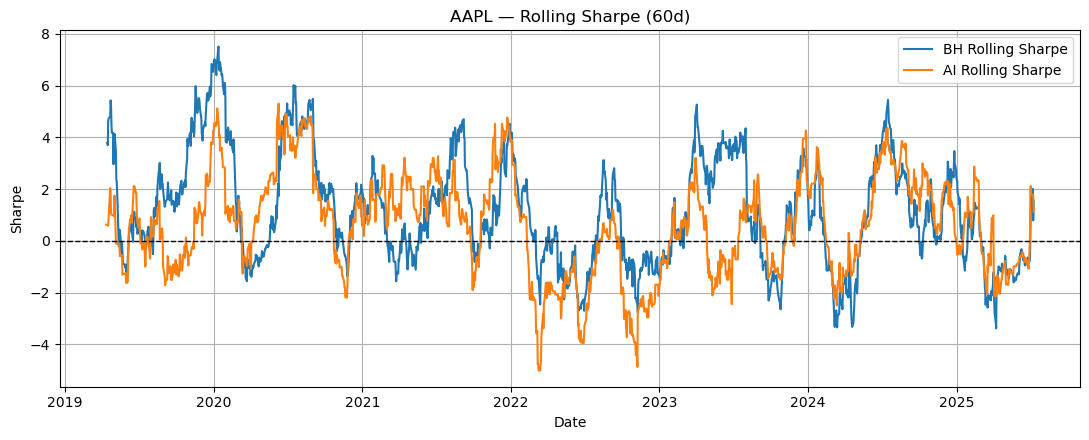

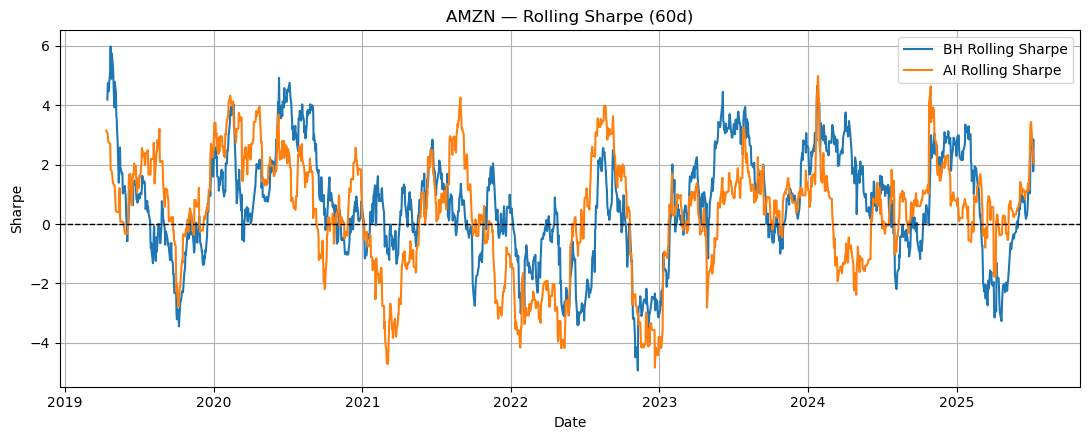

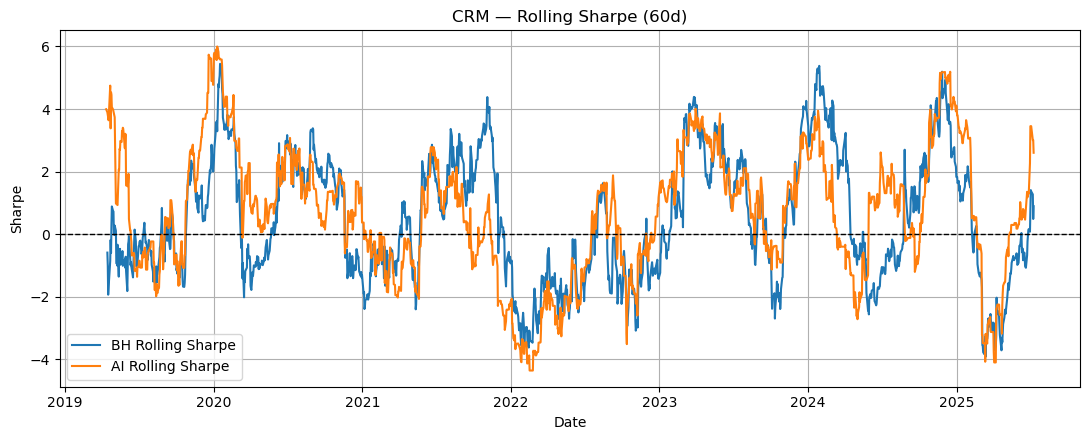

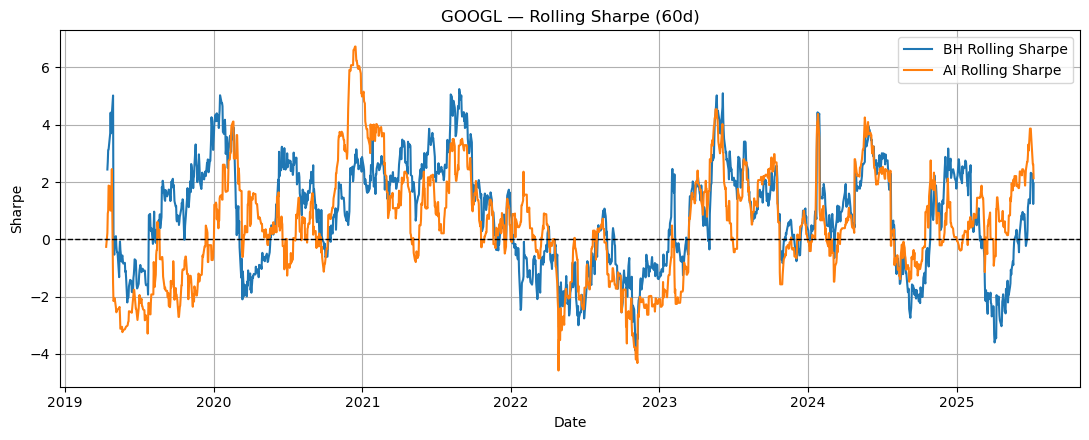

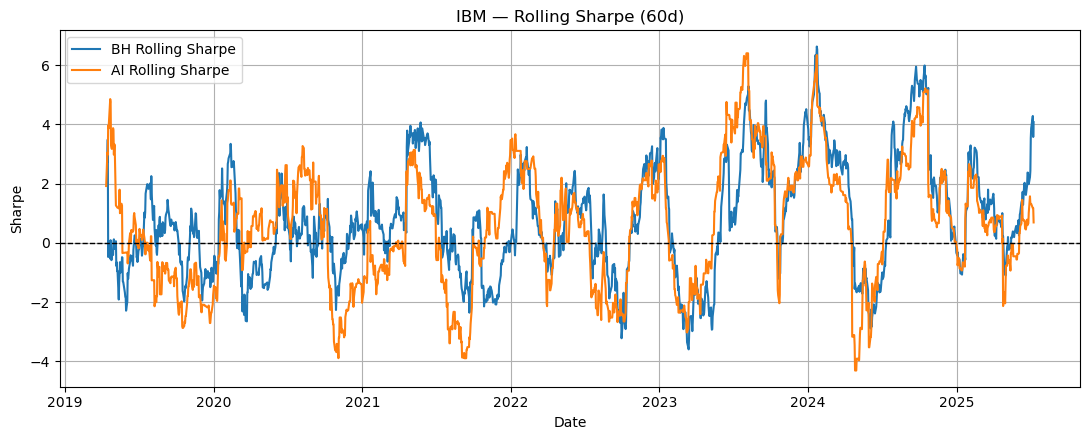

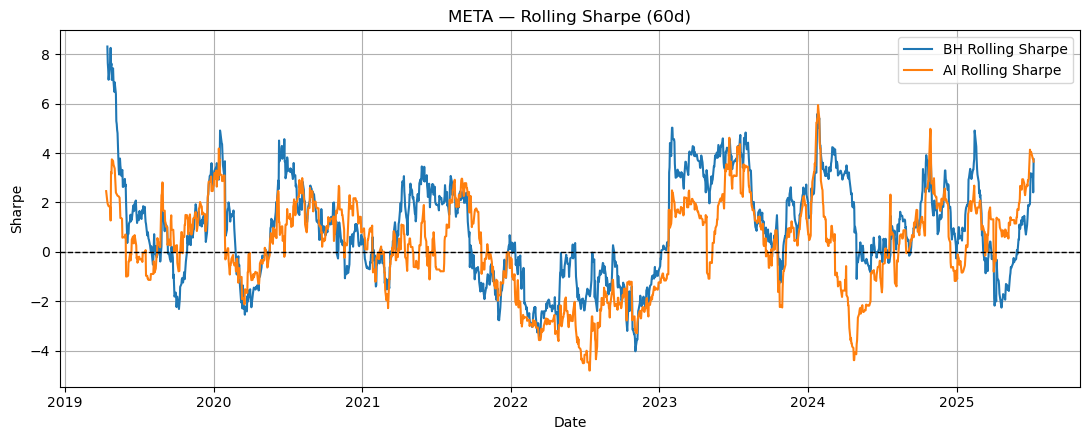

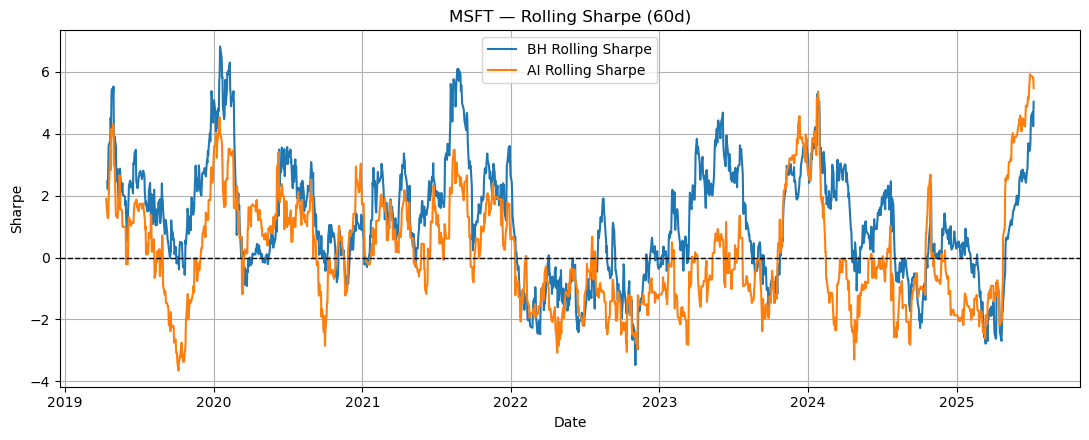

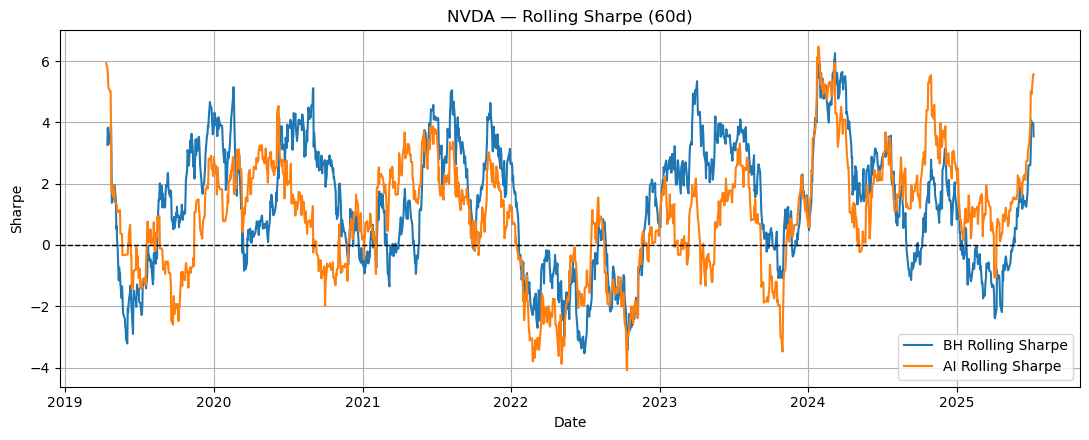

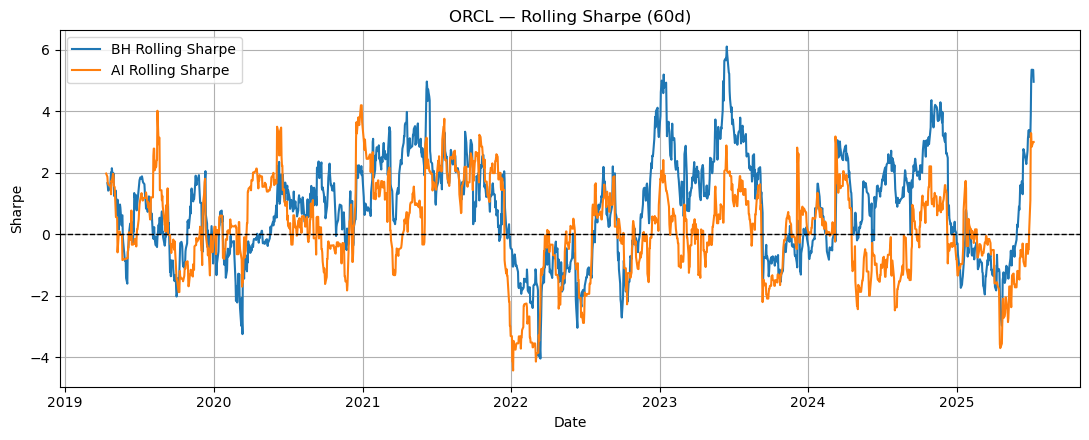

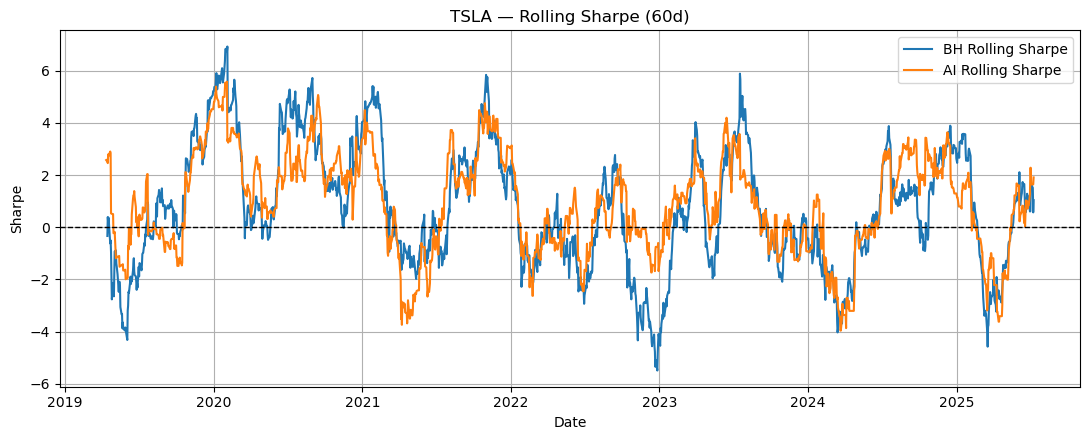

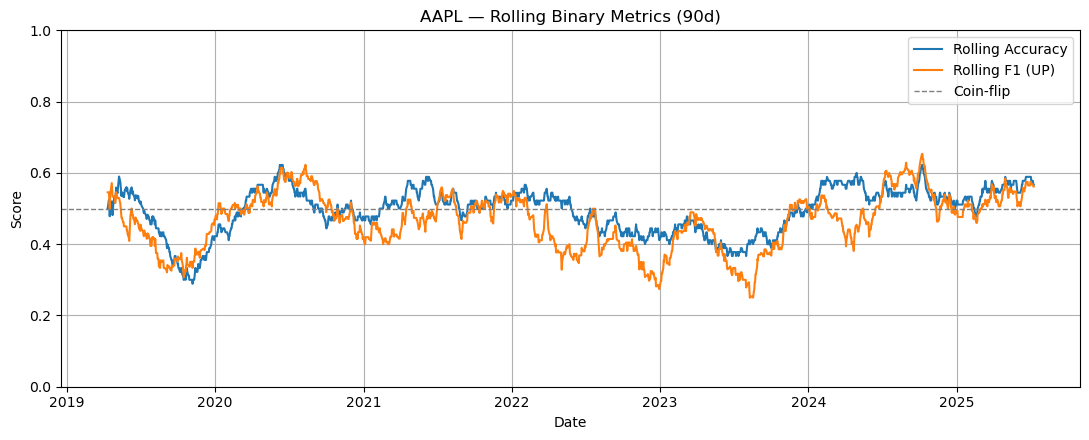

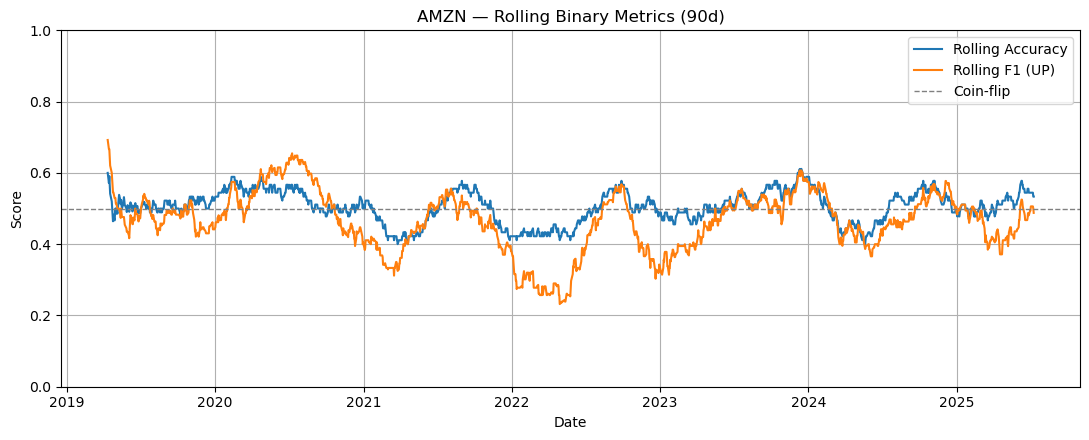

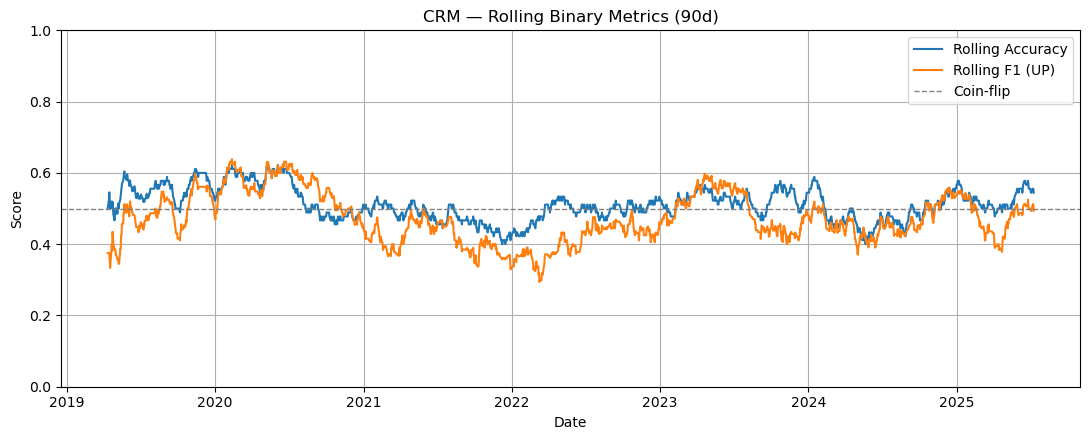

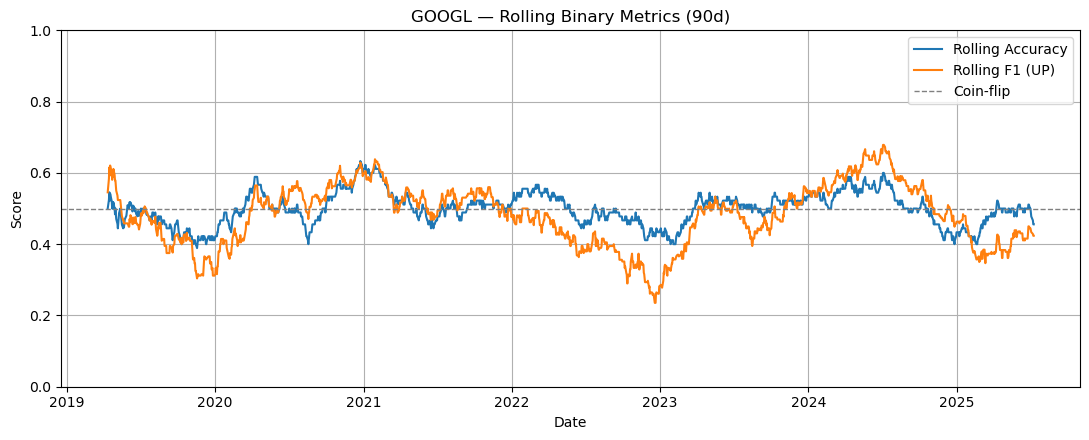

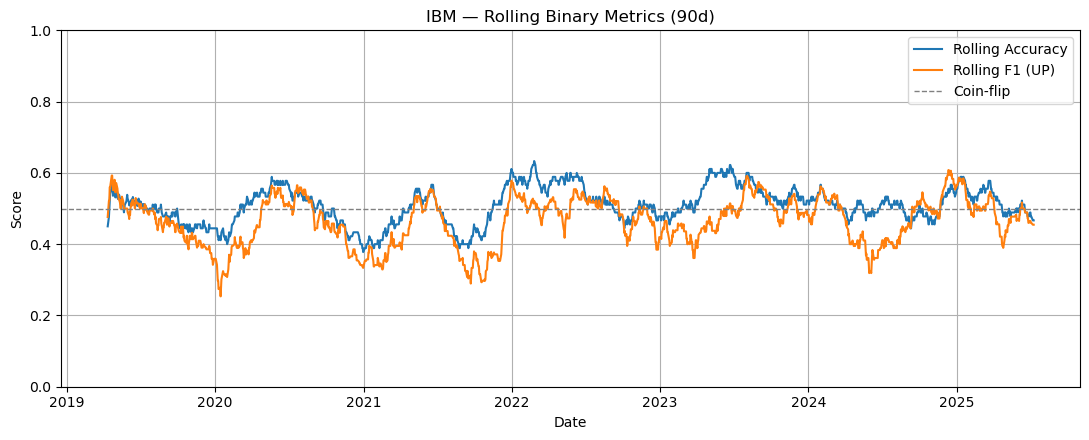

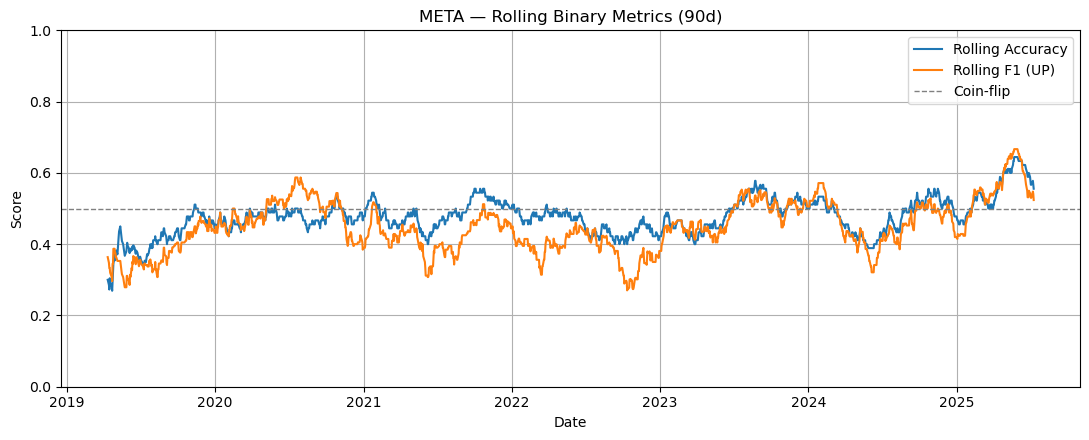

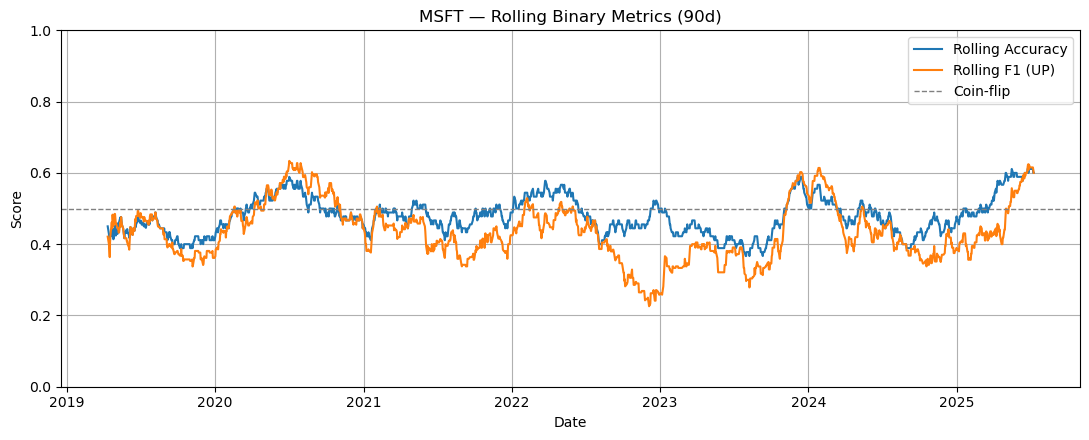

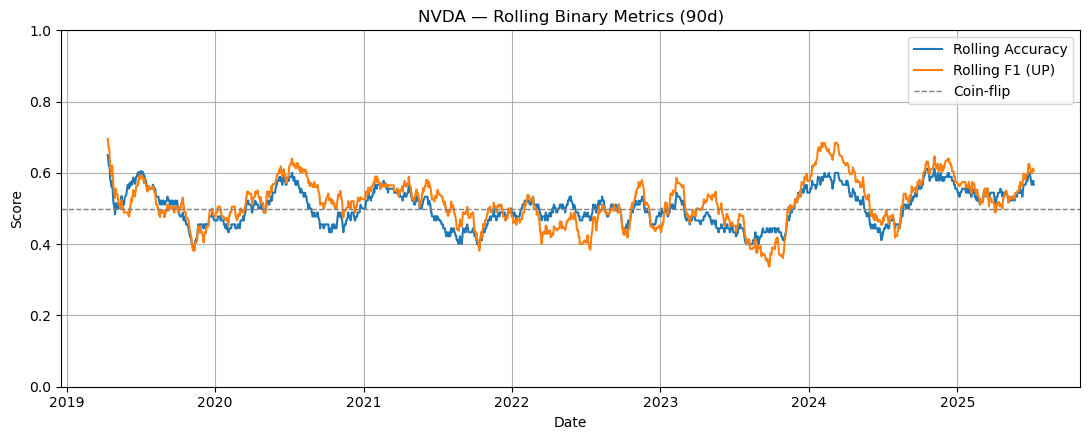

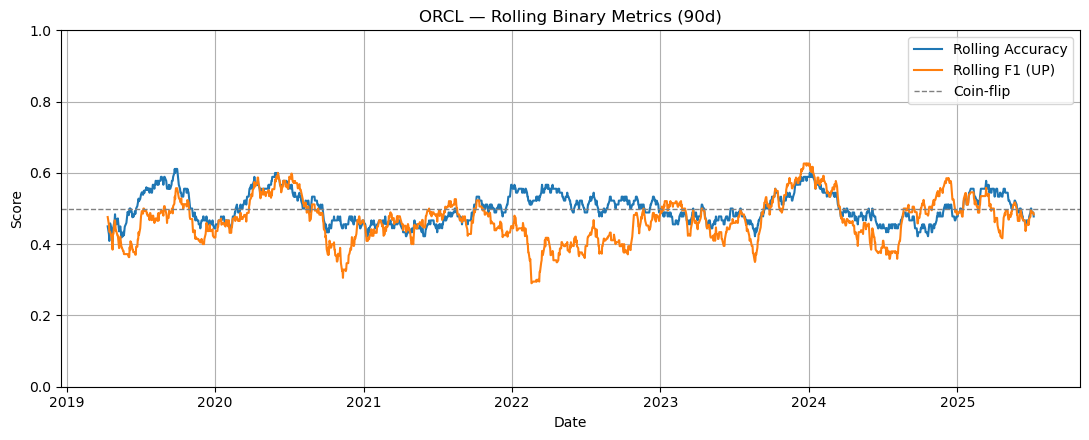

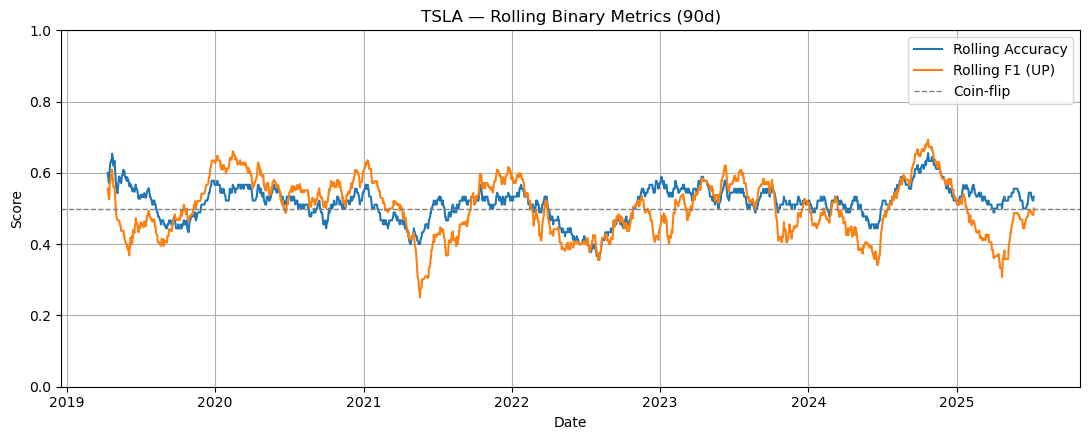

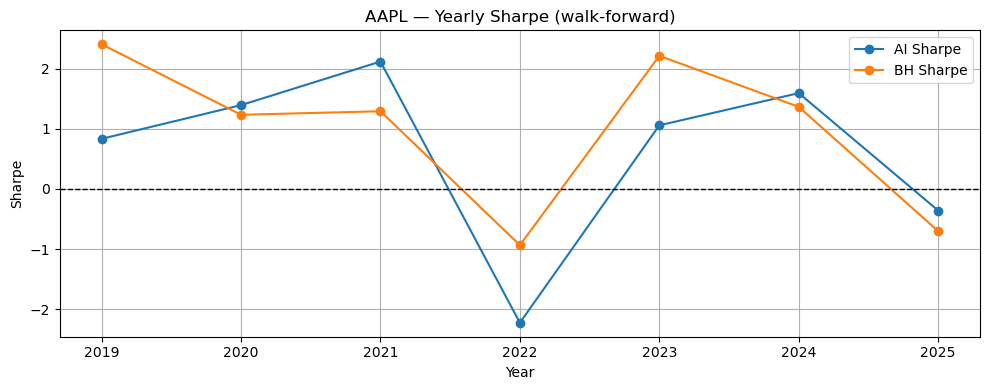

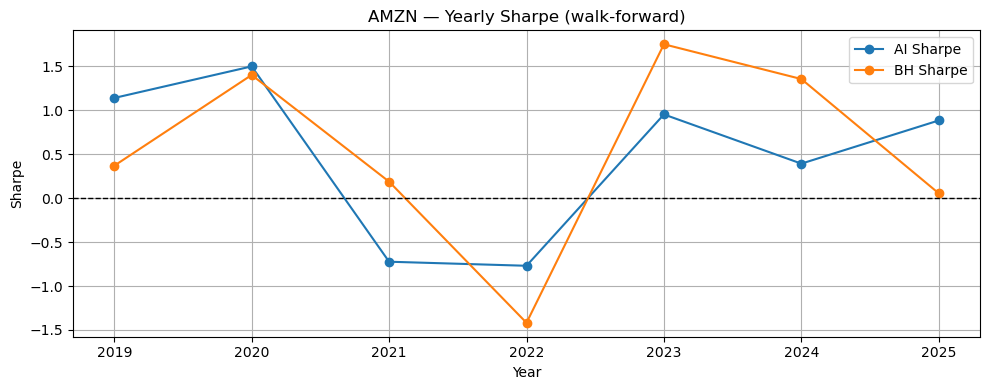

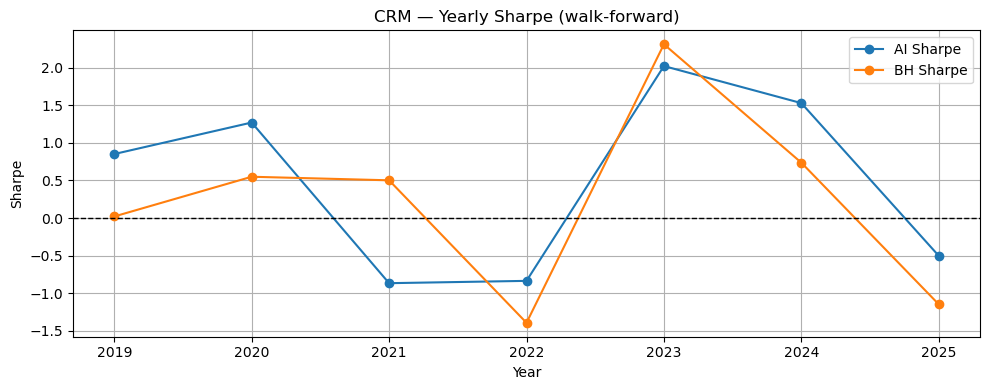

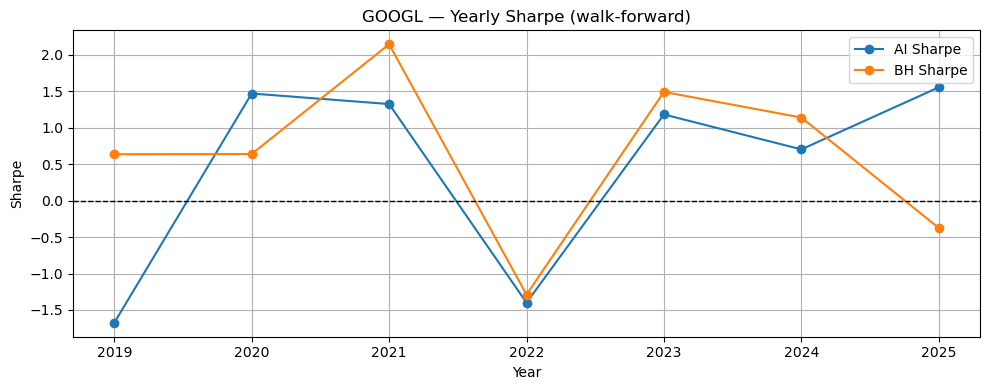

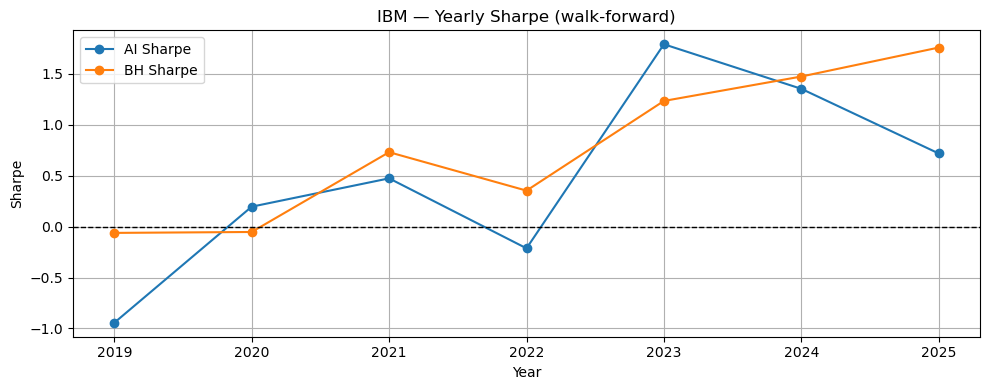

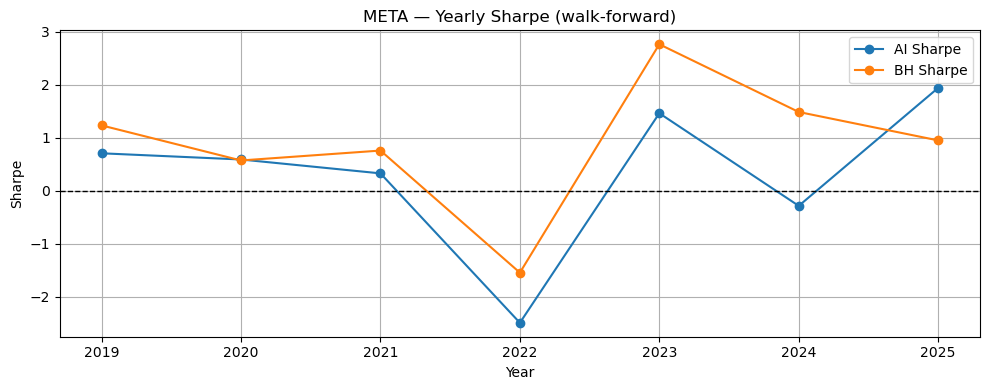

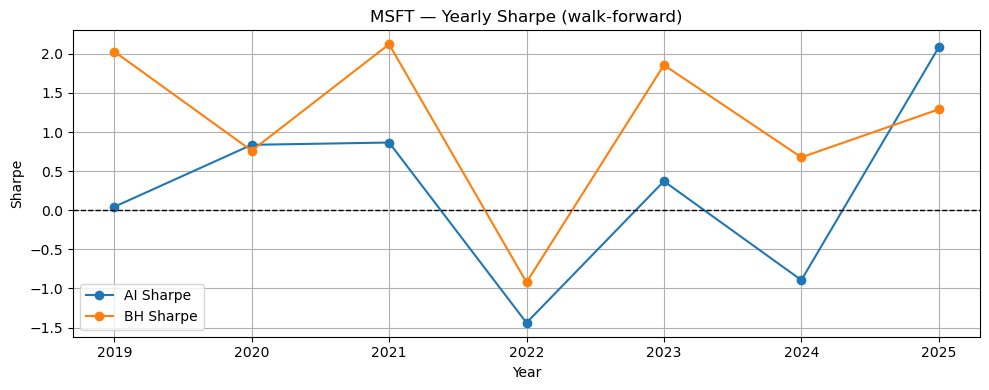

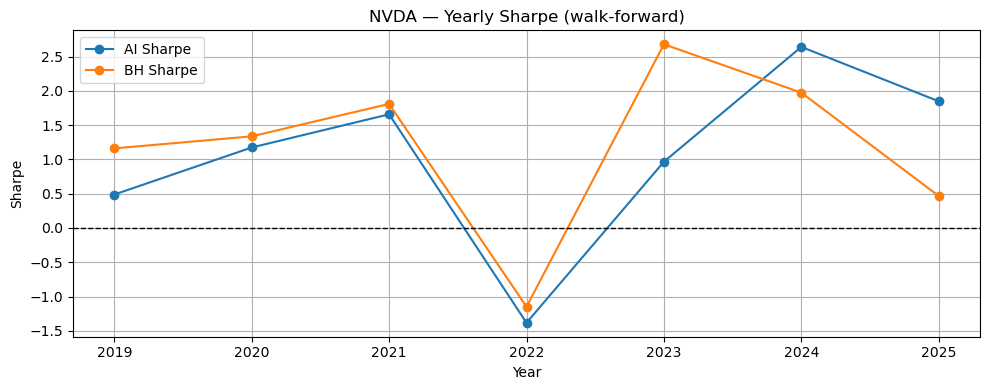

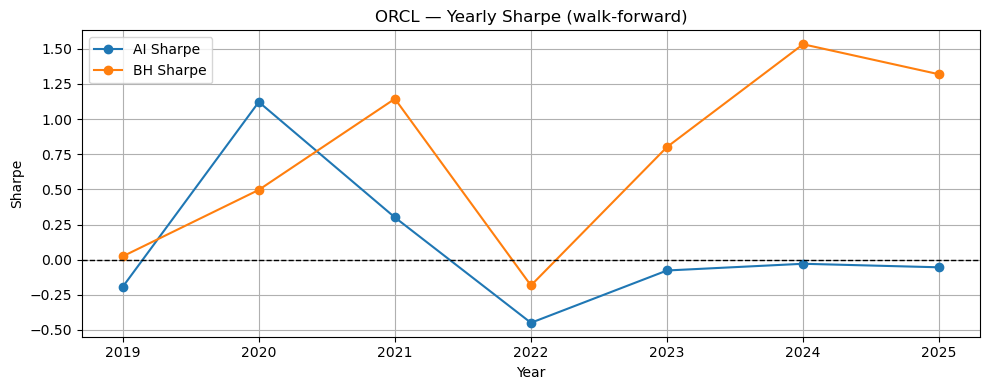

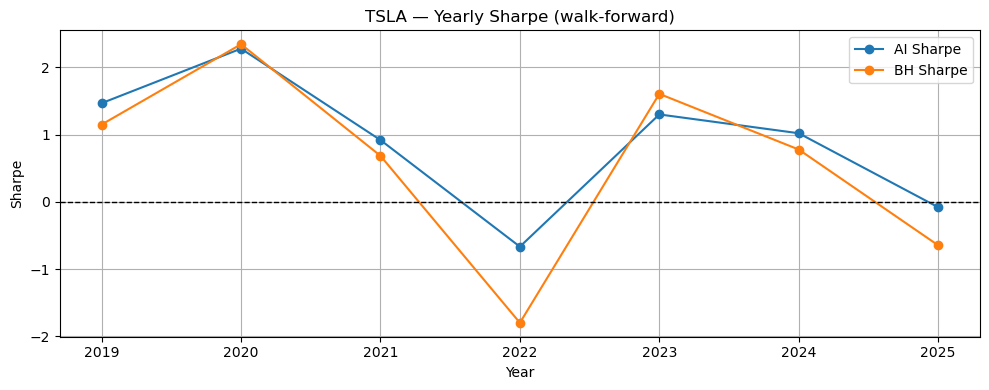


Reliability by Ticker (fraction of years AI > BH):
Ticker  Reliability_Sharpe  Reliability_TotalRet
  AAPL            0.571429              0.285714
  AMZN            0.571429              0.428571
   CRM            0.714286              0.714286
 GOOGL            0.285714              0.428571
   IBM            0.285714              0.142857
  META            0.285714              0.142857
  MSFT            0.285714              0.285714
  NVDA            0.285714              0.285714
  ORCL            0.142857              0.142857
  TSLA            0.714286              0.285714

Overall reliability (mean across tickers):
Reliability_Sharpe      0.414286
Reliability_TotalRet    0.314286
dtype: float64


In [17]:
# Reliability & Stability checks

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROLL_RET_WIN = 60     # trading days for rolling Sharpe
ROLL_CLS_WIN = 90     # days for rolling accuracy/F1
MIN_PERIODS   = 20    # min obs for stats windows

eval_df = pd.read_parquet(REPORT_DIR / "eval_table.parquet").copy()

def rolling_sharpe(returns, win=ROLL_RET_WIN, minp=MIN_PERIODS):
    # daily returns -> rolling Sharpe (annualized)
    r = returns.copy()
    mu = r.rolling(win, min_periods=minp).mean()
    sd = r.rolling(win, min_periods=minp).std()
    sharpe = (mu / sd) * np.sqrt(252)
    return sharpe

def plot_rolling_sharpe(df):
    for ticker in sorted(df['Ticker'].unique()):
        sub = df[df['Ticker']==ticker].sort_values('Date').copy()
        bh_ret = np.log(sub['Close'] / sub['Close'].shift(1))
        ai_ret = sub['StrategyReturn']

        rs_bh = rolling_sharpe(bh_ret)
        rs_ai = rolling_sharpe(ai_ret)

        plt.figure(figsize=(11,4.5))
        plt.plot(sub['Date'], rs_bh, label='BH Rolling Sharpe')
        plt.plot(sub['Date'], rs_ai, label='AI Rolling Sharpe')
        plt.axhline(0, linestyle='--', color='black', linewidth=1)
        plt.title(f"{ticker} — Rolling Sharpe ({ROLL_RET_WIN}d)")
        plt.ylabel("Sharpe"); plt.xlabel("Date"); plt.legend(); plt.grid(True)
        plt.tight_layout(); plt.show()

plot_rolling_sharpe(eval_df)

# binary UP vs NOT_UP
LABELS_3 = ["DOWN","FLAT","UP"]
BIN_MAP = {"DOWN":"NOT_UP","FLAT":"NOT_UP","UP":"UP"}

def rolling_binary_metrics(df, win=ROLL_CLS_WIN, minp=MIN_PERIODS):
    out = []
    for ticker in sorted(df['Ticker'].unique()):
        sub = df[df['Ticker']==ticker].sort_values('Date').copy()
        y_true = pd.Series(pd.Categorical(sub['true_label'], categories=LABELS_3)).map(BIN_MAP).values
        y_pred = pd.Series(pd.Categorical(sub['pred_label'], categories=LABELS_3)).map(BIN_MAP).values

        acc_series = []
        f1_series  = []
        dates      = sub['Date'].values

        for i in range(len(sub)):
            j0 = max(0, i - win + 1)
            y_t = y_true[j0:i+1]
            y_p = y_pred[j0:i+1]
            if len(y_t) >= minp:
                tp = np.sum((y_t=="UP") & (y_p=="UP"))
                fp = np.sum((y_t!="UP") & (y_p=="UP"))
                fn = np.sum((y_t=="UP") & (y_p!="UP"))
                tn = np.sum((y_t!="UP") & (y_p!="UP"))
                acc = (tp+tn) / (tp+tn+fp+fn) if (tp+tn+fp+fn)>0 else np.nan
                prec = tp/(tp+fp) if (tp+fp)>0 else np.nan
                rec  = tp/(tp+fn) if (tp+fn)>0 else np.nan
                f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else np.nan
            else:
                acc, f1 = np.nan, np.nan
            acc_series.append(acc)
            f1_series.append(f1)

        out.append(pd.DataFrame({
            "Date": sub['Date'].values,
            "Ticker": ticker,
            "RollAcc": acc_series,
            "RollF1": f1_series
        }))
    return pd.concat(out, ignore_index=True)

roll_cls = rolling_binary_metrics(eval_df)

def plot_rolling_cls(roll_df):
    for ticker in sorted(roll_df['Ticker'].unique()):
        sub = roll_df[roll_df['Ticker']==ticker]
        plt.figure(figsize=(11,4.5))
        plt.plot(sub['Date'], sub['RollAcc'], label='Rolling Accuracy')
        plt.plot(sub['Date'], sub['RollF1'],  label='Rolling F1 (UP)')
        plt.axhline(0.5, linestyle='--', color='gray', linewidth=1, label='Coin-flip')
        plt.ylim(0,1)
        plt.title(f"{ticker} — Rolling Binary Metrics ({ROLL_CLS_WIN}d)")
        plt.ylabel("Score"); plt.xlabel("Date"); plt.legend(); plt.grid(True)
        plt.tight_layout(); plt.show()

plot_rolling_cls(roll_cls)

# yearly walk-forward stability + reliability score
def yearly_walkforward(df):
    rows = []
    for ticker in sorted(df['Ticker'].unique()):
        sub = df[df['Ticker']==ticker].copy()
        sub['Year'] = pd.to_datetime(sub['Date']).dt.year

        for y, g in sub.groupby('Year'):
            bh_ret = np.log(g['Close'] / g['Close'].shift(1)).fillna(0)
            ai_ret = g['StrategyReturn'].fillna(0)
            mu_ai, sd_ai = ai_ret.mean(), ai_ret.std()
            mu_bh, sd_bh = bh_ret.mean(), bh_ret.std()
            sharpe_ai = (mu_ai/sd_ai*np.sqrt(252)) if sd_ai>0 else np.nan
            sharpe_bh = (mu_bh/sd_bh*np.sqrt(252)) if sd_bh>0 else np.nan
            eq_ai = np.exp(ai_ret.cumsum())
            eq_bh = np.exp(bh_ret.cumsum())
            rows.append({
                "Ticker": ticker, "Year": int(y),
                "AI_Sharpe": sharpe_ai, "BH_Sharpe": sharpe_bh,
                "AI_TR": eq_ai.iloc[-1]-1.0, "BH_TR": eq_bh.iloc[-1]-1.0
            })
    return pd.DataFrame(rows)

wf = yearly_walkforward(eval_df)

def plot_yearly_stability(wf_df, ticker):
    sub = wf_df[wf_df['Ticker']==ticker].sort_values('Year')
    plt.figure(figsize=(10,4))
    plt.plot(sub['Year'], sub['AI_Sharpe'], marker='o', label='AI Sharpe')
    plt.plot(sub['Year'], sub['BH_Sharpe'], marker='o', label='BH Sharpe')
    plt.axhline(0, linestyle='--', color='black', linewidth=1)
    plt.title(f"{ticker} — Yearly Sharpe (walk-forward)")
    plt.xlabel("Year"); plt.ylabel("Sharpe")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

for t in sorted(wf['Ticker'].unique()):
    plot_yearly_stability(wf, t)

# reliability score: % of windows where AI wins
rel = (
    wf.assign(Sharpe_Win = wf['AI_Sharpe'] > wf['BH_Sharpe'],
              TR_Win     = wf['AI_TR']     > wf['BH_TR'])
      .groupby('Ticker')[['Sharpe_Win','TR_Win']]
      .mean()
      .rename(columns={'Sharpe_Win':'Reliability_Sharpe', 'TR_Win':'Reliability_TotalRet'})
      .reset_index()
)
print("\nReliability by Ticker (fraction of years AI > BH):")
print(rel.sort_values('Ticker').to_string(index=False))
print("\nOverall reliability (mean across tickers):")
print(rel[['Reliability_Sharpe','Reliability_TotalRet']].mean())